# Multi-Session Cell Tuning Analysis - CORRECTED

This notebook analyzes tuning properties across **all sessions** in the dataset using **corrected alignment** for STOP/CONT trials.

**IMPORTANT**: STOP/CONT trials are aligned to `stop_cue` (not `go_cue`) to properly measure signal responses.

**Objectives:**
1. Run tuning analysis on all cells across all sessions
2. Generate session-level statistics
3. Compare tuning properties across sessions
4. Identify sessions with high/low proportions of tuned cells
5. Generate comprehensive visualizations
6. Save results for each session

**Key Correction:**
- STOP/CONT trials now aligned to `stop_cue` to measure actual signal responses
- New measures: STOP modulation, CONT modulation, Signal discrimination, GO vs Signals

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import holoviews as hv
import hvplot.pandas
hv.extension('bokeh')

from scipy import stats
from scipy.stats import f_oneway, ttest_ind
from itertools import combinations
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import classes
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from cell_analysis import Cell, PopulationAnalyzer

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


In [2]:
# Analysis windows (ms)
WINDOWS = {
    'baseline': [-300, 0],
    'go_task': [-100, 100],
    'direction': [100, 400],
    'signal': [100, 400],
}

print('✓ Analysis windows set:', WINDOWS)


✓ Analysis windows set: {'baseline': [-300, 0], 'go_task': [-100, 100], 'direction': [100, 400], 'signal': [100, 400]}


## 1. Helper Functions - CORRECTED

In [3]:
def get_firing_rates(cell, align_event, window, trial_type=None, direction=None, success_only=True):
    """
    Extract firing rates for specific conditions.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    align_event : str
        'go_cue' or 'stop_cue'
    window : list
        Time window [start, end] in ms
    trial_type : str, optional
        'GO', 'STOP', or 'CONT'
    direction : int, optional
        0 (right) or 180 (left)
    success_only : bool
        Include only successful trials
    
    Returns:
    --------
    np.array : Firing rates in spikes/sec
    """
    cell.align_spikes_to_event(align_event)
    df = cell.filter_trials(trial_type=trial_type, direction=direction, success_only=success_only)
    
    rates = []
    for _, row in df.iterrows():
        # if align_event == 'go_cue':
        #     t0 = row['go_cue']
        # elif align_event == 'stop_cue':
        #     t0 = row['stop_cue']
        # else:
        #     raise ValueError(f"Unknown align_event: {align_event}")
        
        # if pd.isna(t0):
        #     continue
            
        # spikes = np.array(row['neural_data'], dtype=float)
        aligned_spikes = np.array(row[f'spikes_aligned_to_{align_event}'], dtype=float)
        # aligned_spikes = spikes - t0
        
        count = np.sum((aligned_spikes >= window[0]) & (aligned_spikes <= window[1]))
        duration = (window[1] - window[0]) / 1000.0
        rates.append(count / duration)
        
    return np.array(rates)

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def eta_squared(groups):
    """Calculate eta-squared effect size for ANOVA."""
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = np.sum((all_data - grand_mean)**2)
    
    if ss_total == 0:
        return 0.0
    
    return ss_between / ss_total

def direction_selectivity_index(left_rate, right_rate):
    """Calculate direction selectivity index."""
    if left_rate + right_rate == 0:
        return 0.0
    return (left_rate - right_rate) / (left_rate + right_rate)

def modulation_index(baseline_rate, task_rate):
    """Calculate modulation index."""
    if baseline_rate + task_rate == 0:
        return 0.0
    return (task_rate - baseline_rate) / (task_rate + baseline_rate)

def signal_selectivity_index(stop_rate, cont_rate):
    """Calculate signal selectivity index (STOP vs CONT)."""
    if stop_rate + cont_rate == 0:
        return 0.0
    return (stop_rate - cont_rate) / (stop_rate + cont_rate)

def analyze_cell_tuning(cell, alpha=0.05, verbose=False):
    """
    Comprehensive tuning analysis with CORRECTED alignment for STOP/CONT trials.
    
    Key fix: STOP and CONT trials are aligned to stop_cue, not go_cue.
    
    Parameters:
    -----------
    cell : Cell
        Cell object to analyze
    alpha : float
        Significance level (default: 0.05)
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : Comprehensive tuning results
    """
    results = {
        'cell_id': cell.cell_id,
        'cell_type': cell.cell_type,
    }
    
    n_tests = 6  # Increased: task_mod, direction, stop_mod, cont_mod, signal_discrimination, go_vs_signal
    bonferroni_alpha = alpha / n_tests
    
    # ========================================
    # 1. BASELINE (from GO trials)
    # ========================================
    baseline_rates = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO')
    
    # ========================================
    # 2. TASK MODULATION (Baseline vs GO)
    # ========================================
    # go_rates = get_firing_rates(cell, 'go_cue', WINDOWS['go_task'], trial_type='GO')
    go_rates = get_firing_rates(cell, 'first_relevant_saccade', WINDOWS['go_task'], trial_type='GO')
    
    if len(baseline_rates) > 0 and len(go_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, go_rates)
        effect_size = cohens_d(go_rates, baseline_rates)
        eta2 = eta_squared([baseline_rates, go_rates])
        
        results['task_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'eta_squared': eta2,
            'modulation_index': modulation_index(np.mean(baseline_rates), np.mean(go_rates)),
            'baseline_mean': np.mean(baseline_rates),
            'go_mean': np.mean(go_rates)
        }
    else:
        results['task_modulation'] = {'significant': False}
    
    # ========================================
    # 3. DIRECTION TUNING (on GO trials)
    # ========================================
    # go_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
    # go_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)
    go_left = get_firing_rates(cell, 'first_relevant_saccade', WINDOWS['go_task'], trial_type='GO', direction=180)
    go_right = get_firing_rates(cell, 'first_relevant_saccade', WINDOWS['go_task'], trial_type='GO', direction=0)
    
    if len(go_left) > 0 and len(go_right) > 0:
        f_stat, p_val = f_oneway(go_left, go_right)
        effect_size = cohens_d(go_left, go_right)
        dsi = direction_selectivity_index(np.mean(go_left), np.mean(go_right))
        
        results['direction_tuning'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'direction_selectivity_index': dsi,
            'preferred_direction': 'left' if dsi > 0 else 'right',
            'left_mean': np.mean(go_left),
            'right_mean': np.mean(go_right)
        }
    else:
        results['direction_tuning'] = {'significant': False}
    
    # ========================================
    # 4. STOP MODULATION (Baseline vs STOP response)
    # CORRECTED: Align to stop_cue!
    # ========================================
    stop_rates = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type='STOP')
    
    if len(baseline_rates) > 0 and len(stop_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, stop_rates)
        effect_size = cohens_d(stop_rates, baseline_rates)
        mi = modulation_index(np.mean(baseline_rates), np.mean(stop_rates))
        
        results['stop_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'modulation_index': mi,
            'stop_mean': np.mean(stop_rates)
        }
    else:
        results['stop_modulation'] = {'significant': False}
    
    # ========================================
    # 5. CONT MODULATION (Baseline vs CONT response)
    # CORRECTED: Align to stop_cue!
    # ========================================
    cont_rates = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type='CONT')
    
    if len(baseline_rates) > 0 and len(cont_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, cont_rates)
        effect_size = cohens_d(cont_rates, baseline_rates)
        mi = modulation_index(np.mean(baseline_rates), np.mean(cont_rates))
        
        results['cont_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'modulation_index': mi,
            'cont_mean': np.mean(cont_rates)
        }
    else:
        results['cont_modulation'] = {'significant': False}
    
    # ========================================
    # 6. SIGNAL DISCRIMINATION (STOP vs CONT)
    # Both aligned to stop_cue
    # ========================================
    if len(stop_rates) > 0 and len(cont_rates) > 0:
        f_stat, p_val = f_oneway(stop_rates, cont_rates)
        effect_size = cohens_d(stop_rates, cont_rates)
        ssi = signal_selectivity_index(np.mean(stop_rates), np.mean(cont_rates))
        
        results['signal_discrimination'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'signal_selectivity_index': ssi,
            'preferred_signal': 'STOP' if ssi > 0 else 'CONT'
        }
    else:
        results['signal_discrimination'] = {'significant': False}
    
    # ========================================
    # 7. GO vs SIGNALS (does signal differ from GO?)
    # ========================================
    if len(go_rates) > 0 and len(stop_rates) > 0 and len(cont_rates) > 0:
        f_stat_stop, p_val_stop = f_oneway(go_rates, stop_rates)
        d_stop = cohens_d(go_rates, stop_rates)
        
        f_stat_cont, p_val_cont = f_oneway(go_rates, cont_rates)
        d_cont = cohens_d(go_rates, cont_rates)
        
        f_stat_all, p_val_all = f_oneway(go_rates, stop_rates, cont_rates)
        
        results['go_vs_signals'] = {
            'F_overall': f_stat_all,
            'p_overall': p_val_all,
            'p_bonferroni': p_val_all * n_tests,
            'significant': p_val_all < bonferroni_alpha,
            'go_vs_stop_p': p_val_stop,
            'go_vs_stop_d': d_stop,
            'go_vs_cont_p': p_val_cont,
            'go_vs_cont_d': d_cont
        }
    else:
        results['go_vs_signals'] = {'significant': False}
    
    # ========================================
    # SUMMARY CLASSIFICATION
    # ========================================
    results['summary'] = {
        'is_task_modulated': results['task_modulation'].get('significant', False),
        'is_direction_tuned': results['direction_tuning'].get('significant', False),
        'is_stop_modulated': results['stop_modulation'].get('significant', False),
        'is_cont_modulated': results['cont_modulation'].get('significant', False),
        'is_signal_discriminative': results['signal_discrimination'].get('significant', False),
        'is_go_vs_signal_different': results['go_vs_signals'].get('significant', False),
    }
    
    # Build tuning profile
    profile = []
    if results['summary']['is_task_modulated']:
        profile.append('task_modulated')
    if results['summary']['is_direction_tuned']:
        profile.append(f"direction_tuned_{results['direction_tuning'].get('preferred_direction', 'none')}")
    if results['summary']['is_stop_modulated']:
        profile.append('stop_modulated')
    if results['summary']['is_cont_modulated']:
        profile.append('cont_modulated')
    if results['summary']['is_signal_discriminative']:
        profile.append(f"signal_selective_{results['signal_discrimination'].get('preferred_signal', 'none')}")
    if results['summary']['is_go_vs_signal_different']:
        profile.append('go_vs_signal_different')
    
    results['summary']['tuning_profile'] = profile if profile else ['not_tuned']
    results['summary']['preferred_direction'] = results['direction_tuning'].get('preferred_direction', 'none')
    
    return results
print("✓ Helper functions defined (CORRECTED)")


✓ Helper functions defined (CORRECTED)


## 2. Load Data

In [4]:
# Load MSN cell database
monkey = 'fiona'
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
# pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'
pickle_file = base_path / f'alt_saccade_params_msn_{monkey}_cell_trial_data.pkl'
cell_df = pd.read_pickle(pickle_file)

print(f"Loaded {len(cell_df):,} trials")
print(f"\nSessions: {cell_df['trial_session'].nunique()}")
print(f"Unique cells: {cell_df['cell_ID'].nunique()}")

Loaded 1,939,269 trials

Sessions: 61
Unique cells: 3096


## 3. Session Overview

In [5]:
# Get session statistics
session_stats = []

for session_id in cell_df['trial_session'].unique():
    session_data = cell_df[cell_df['trial_session'] == session_id]
    
    session_stats.append({
        'session_id': session_id,
        'n_cells': session_data['cell_ID'].nunique(),
        'n_trials': len(session_data),
        'n_go': len(session_data[session_data['type'] == 'GO']),
        'n_stop': len(session_data[session_data['type'] == 'STOP']),
        'n_cont': len(session_data[session_data['type'] == 'CONT']),
    })

session_stats_df = pd.DataFrame(session_stats).sort_values('n_cells', ascending=False)

print("\nSession Statistics (sorted by number of cells):")
print("="*80)
display(session_stats_df)

print(f"\nTotal sessions: {len(session_stats_df)}")
print(f"Mean cells per session: {session_stats_df['n_cells'].mean():.1f}")
print(f"Median cells per session: {session_stats_df['n_cells'].median():.1f}")
print(f"Range: {session_stats_df['n_cells'].min()} - {session_stats_df['n_cells'].max()} cells")


Session Statistics (sorted by number of cells):


,session_id,n_cells,n_trials,n_go,n_stop,n_cont
41,fi211102a,189,88122,48783,19409,19930
24,fi211025a,155,107982,59205,24019,24758
60,fi211110a,146,105459,58096,22569,24794
20,fi211122a,132,62311,34763,13134,14414
2,fi211109a,132,88779,49470,18631,20678
...,...,...,...,...,...,...
38,fi210712a,2,609,342,120,147
28,fi210704a,1,100,58,16,26
25,fi210707a,1,314,174,69,71
29,fi211010a,1,567,319,125,123



Total sessions: 61
Mean cells per session: 50.8
Median cells per session: 34.0
Range: 1 - 189 cells


## 4. Analyze All Sessions

In [6]:
# Analyze all cells across all sessions
all_results = []
session_ids = cell_df['trial_session'].unique()

print(f"Analyzing {len(session_ids)} sessions...\n")

for session_id in tqdm(session_ids, desc="Sessions"):
    session_data = cell_df[cell_df['trial_session'] == session_id]
    session = Session(session_data, verbose=False)

    if len(session.cell_ids) < 15:
        continue
    
    for cell_id in session.cell_ids:
        cell = session.get_cell(cell_id)
        result = analyze_cell_tuning(cell, verbose=False)
        result['session_id'] = session_id
        all_results.append(result)

print(f"\n✓ Analysis complete: {len(all_results)} cells analyzed")

Analyzing 61 sessions...



Sessions:   0%|          | 0/61 [00:00<?, ?it/s]


✓ Analysis complete: 3075 cells analyzed


## 5. Create Summary DataFrames - CORRECTED

In [7]:
# Create comprehensive summary DataFrame
summary_data = []

for res in all_results:
    summary_data.append({
        'session_id': res['session_id'],
        'cell_id': res['cell_id'],
        'cell_type': res['cell_type'],
        'is_task_modulated': res['summary']['is_task_modulated'],
        'is_direction_tuned': res['summary']['is_direction_tuned'],
        'is_stop_modulated': res['summary']['is_stop_modulated'],
        'is_cont_modulated': res['summary']['is_cont_modulated'],
        'is_signal_discriminative': res['summary']['is_signal_discriminative'],
        'is_go_vs_signal_different': res['summary']['is_go_vs_signal_different'],
        'preferred_direction': res['summary']['preferred_direction'],
        'preferred_signal': res['signal_discrimination'].get('preferred_signal', 'none'),
        'tuning_profile': ', '.join(res['summary']['tuning_profile']),
        'task_mod_p': res['task_modulation'].get('p', np.nan),
        'dir_tuning_p': res['direction_tuning'].get('p', np.nan),
        'stop_mod_p': res['stop_modulation'].get('p', np.nan),
        'cont_mod_p': res['cont_modulation'].get('p', np.nan),
        'signal_disc_p': res['signal_discrimination'].get('p', np.nan),
        'go_vs_signal_p': res['go_vs_signals'].get('p_overall', np.nan),
        'baseline_FR': res['task_modulation'].get('baseline_mean', np.nan),
        'go_FR': res['task_modulation'].get('go_mean', np.nan),
        'stop_FR': res['stop_modulation'].get('stop_mean', np.nan),
        'cont_FR': res['cont_modulation'].get('cont_mean', np.nan),
        'DSI': res['direction_tuning'].get('direction_selectivity_index', np.nan),
        'SSI': res['signal_discrimination'].get('signal_selectivity_index', np.nan),
        'task_MI': res['task_modulation'].get('modulation_index', np.nan),
        'cohens_d_direction': res['direction_tuning'].get('cohens_d', np.nan),
        'cohens_d_task': res['task_modulation'].get('cohens_d', np.nan),
    })

summary_df = pd.DataFrame(summary_data)

print("Summary DataFrame created (CORRECTED)")
print(f"Shape: {summary_df.shape}")
display(summary_df.head(10))

Summary DataFrame created (CORRECTED)
Shape: (3075, 27)


,session_id,cell_id,cell_type,is_task_modulated,is_direction_tuned,is_stop_modulated,is_cont_modulated,is_signal_discriminative,is_go_vs_signal_different,preferred_direction,...,go_vs_signal_p,baseline_FR,go_FR,stop_FR,cont_FR,DSI,SSI,task_MI,cohens_d_direction,cohens_d_task
0,fi210819a,9750,msn,True,False,False,True,True,True,right,...,3.159489e-09,4.602369,2.284264,5.172414,2.357724,-0.010870,0.373790,-0.336609,-0.015225,-0.703616
1,fi210819a,9751,msn,False,True,True,True,False,False,right,...,8.452793e-02,3.271605,2.777778,2.105263,2.079772,-0.424411,0.006091,-0.081633,-0.630568,-0.138947
2,fi210819a,9753,msn,False,False,False,False,False,False,right,...,2.314611e-02,3.225030,3.411552,2.636816,2.114695,-0.040193,0.109885,0.028105,-0.067034,0.047601
3,fi210819a,9755,msn,True,False,True,True,True,True,right,...,2.050037e-16,8.652263,10.478395,17.149123,11.196581,-0.074164,0.209998,0.095456,-0.256756,0.308619
4,fi210819a,9756,msn,False,False,True,True,True,True,left,...,1.846640e-30,0.349794,0.293210,3.201754,0.997151,0.077223,0.525042,-0.088000,0.036521,-0.044225
5,fi210819a,9757,msn,True,False,False,False,False,True,right,...,7.953592e-05,1.543210,2.839506,1.929825,1.225071,-0.007924,0.223384,0.295775,-0.011375,0.400218
6,fi210819a,9759,msn,False,False,False,False,False,False,right,...,1.739417e-01,2.808642,3.580247,2.587719,3.532764,-0.104954,-0.154407,0.120773,-0.172199,0.200369
7,fi210819a,9760,msn,False,False,False,True,False,False,left,...,6.403735e-02,1.440329,1.543210,1.535088,2.279202,0.064628,-0.195086,0.034483,0.063623,0.035897
8,fi210819a,9761,msn,True,False,True,True,False,False,right,...,9.221114e-01,2.602881,1.651235,1.535088,1.566952,-0.153552,-0.010272,-0.223700,-0.173788,-0.320003
9,fi210819a,9763,msn,True,False,True,True,False,True,left,...,4.628174e-03,4.341564,7.160494,9.385965,7.435897,0.106373,0.115925,0.245081,0.289728,0.630889


## 6. Overall Population Statistics - CORRECTED

In [8]:
print("\n" + "="*80)
print("OVERALL POPULATION STATISTICS (CORRECTED ANALYSIS)")
print("="*80)

total_cells = len(summary_df)
print(f"\nTotal cells analyzed: {total_cells}")
print(f"Total sessions: {summary_df['session_id'].nunique()}")

print(f"\n{'='*80}")
print("TUNING PROPERTIES (across all sessions):")
print(f"{'='*80}")

task_mod = summary_df['is_task_modulated'].sum()
dir_tuned = summary_df['is_direction_tuned'].sum()
stop_mod = summary_df['is_stop_modulated'].sum()
cont_mod = summary_df['is_cont_modulated'].sum()
signal_disc = summary_df['is_signal_discriminative'].sum()
go_vs_sig = summary_df['is_go_vs_signal_different'].sum()

print(f"  Task modulated (GO):       {task_mod:4d} / {total_cells} ({task_mod/total_cells*100:5.1f}%)")
print(f"  Direction tuned:           {dir_tuned:4d} / {total_cells} ({dir_tuned/total_cells*100:5.1f}%)")
print(f"  STOP modulated:            {stop_mod:4d} / {total_cells} ({stop_mod/total_cells*100:5.1f}%)")
print(f"  CONT modulated:            {cont_mod:4d} / {total_cells} ({cont_mod/total_cells*100:5.1f}%)")
print(f"  Signal discriminative:     {signal_disc:4d} / {total_cells} ({signal_disc/total_cells*100:5.1f}%)")
print(f"  GO vs Signal different:    {go_vs_sig:4d} / {total_cells} ({go_vs_sig/total_cells*100:5.1f}%)")

print(f"\n{'='*80}")
print("DIRECTION PREFERENCES (among direction-tuned cells):")
print(f"{'='*80}")

dir_tuned_cells = summary_df[summary_df['is_direction_tuned']]
if len(dir_tuned_cells) > 0:
    dir_counts = dir_tuned_cells['preferred_direction'].value_counts()
    for direction, count in dir_counts.items():
        print(f"  {direction.capitalize():10s}: {count:4d} ({count/len(dir_tuned_cells)*100:5.1f}%)")
else:
    print("  No direction-tuned cells found")

print(f"\n{'='*80}")
print("SIGNAL PREFERENCES (among signal-discriminative cells):")
print(f"{'='*80}")

sig_disc_cells = summary_df[summary_df['is_signal_discriminative']]
if len(sig_disc_cells) > 0:
    sig_counts = sig_disc_cells['preferred_signal'].value_counts()
    for signal, count in sig_counts.items():
        print(f"  {signal:10s}: {count:4d} ({count/len(sig_disc_cells)*100:5.1f}%)")
else:
    print("  No signal-discriminative cells found")

print(f"\n{'='*80}")
print("MOST COMMON TUNING PROFILES:")
print(f"{'='*80}")

profile_counts = summary_df['tuning_profile'].value_counts().head(10)
for profile, count in profile_counts.items():
    print(f"  {profile:60s}: {count:4d} ({count/total_cells*100:5.1f}%)")


OVERALL POPULATION STATISTICS (CORRECTED ANALYSIS)

Total cells analyzed: 3075
Total sessions: 51

TUNING PROPERTIES (across all sessions):
  Task modulated (GO):       1020 / 3075 ( 33.2%)
  Direction tuned:            571 / 3075 ( 18.6%)
  STOP modulated:             925 / 3075 ( 30.1%)
  CONT modulated:            1071 / 3075 ( 34.8%)
  Signal discriminative:      454 / 3075 ( 14.8%)
  GO vs Signal different:     764 / 3075 ( 24.8%)

DIRECTION PREFERENCES (among direction-tuned cells):
  Right     :  386 ( 67.6%)
  Left      :  185 ( 32.4%)

SIGNAL PREFERENCES (among signal-discriminative cells):
  STOP      :  232 ( 51.1%)
  CONT      :  222 ( 48.9%)

MOST COMMON TUNING PROFILES:
  not_tuned                                                   : 1370 ( 44.6%)
  task_modulated, stop_modulated, cont_modulated              :  176 (  5.7%)
  task_modulated                                              :  125 (  4.1%)
  cont_modulated                                              :  110 (  

In [9]:
summary_df[['is_task_modulated', 'is_direction_tuned', 'preferred_direction']]
go_neurons_df = summary_df[summary_df['is_task_modulated'] & summary_df['is_direction_tuned'] & (summary_df['preferred_direction'] == 'right')]

go_neurons = go_neurons_df['cell_id'].tolist()

In [14]:
import numpy as np
import holoviews as hv
from holoviews import opts
from concurrent import futures 

SMOOTH_SIGMA = 20
BIN_SIZE = 1
CONTRA_DIR = 0  # Assuming 0 is the contralateral direction for this monkey

# Calculate mean PSTH values for each neuron in both conditions
def process_neuron_psth_stats_new(cell_id: int) -> dict:
    """Calculate mean PSTH and SEM for a single neuron in both conditions"""
    try:
        return_dict = {'cell_ID': cell_id}
        c = Cell(cell_df[cell_df["cell_ID"] == cell_id])
        for trial_type in ['GO', 'STOP', 'CONT']:
            # Saccade-aligned condition
            success_var = False if trial_type == 'STOP' else True
            bin_centers, firing_rate, _ = c.calculate_psth(
                alignment_point="first_relevant_saccade",
                epok=[-300, 300],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
            
            # Baseline-aligned condition
            baseline_bin_centers, baseline_firing_rate, _ = c.calculate_psth(
                alignment_point="go_cue",
                epok=[-400, 0],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
        
            return_dict.update({
                f'y_baseline_{trial_type}': baseline_firing_rate,
                f'baseline_time_{trial_type}': baseline_bin_centers,
                f'y_saccade_{trial_type}': firing_rate,
                f'saccade_time_{trial_type}': bin_centers
            })
        return return_dict
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return None

# Process neurons in parallel
neuron_ids = sorted(list(go_neurons))
# neuron_ids = cell_df['cell_ID'].unique().tolist()  # Process all neurons for comprehensive stats
print(f"Processing {len(neuron_ids)} neurons in parallel...")

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(process_neuron_psth_stats_new, cid): cid for cid in neuron_ids}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(neuron_ids), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)

neuron_stats_df = pd.DataFrame(neuron_stats).sort_values('cell_ID').reset_index(drop=True)

neuron_stats_df.head()

Processing 262 neurons in parallel...


Calculating PSTH stats:   0%|          | 0/262 [00:00<?, ?it/s]

,cell_ID,y_baseline_GO,baseline_time_GO,y_saccade_GO,saccade_time_GO,y_baseline_STOP,baseline_time_STOP,y_saccade_STOP,saccade_time_STOP,y_baseline_CONT,baseline_time_CONT,y_saccade_CONT,saccade_time_CONT
0,63,"[17.366925049857482, 17.237157716126074, 16.18...","[-400, -399, -398, -397, -396, -395, -394, -39...","[12.930513207331614, 12.1241461827686, 11.1079...","[-300, -299, -298, -297, -296, -295, -294, -29...","[18.84116666535936, 20.117562317133338, 17.220...","[-400, -399, -398, -397, -396, -395, -394, -39...","[23.627281795574632, 24.828589051131065, 23.09...","[-300, -299, -298, -297, -296, -295, -294, -29...","[14.434044621611669, 14.31117120167982, 14.050...","[-400, -399, -398, -397, -396, -395, -394, -39...","[21.28705387057354, 21.50870858114229, 20.0301...","[-300, -299, -298, -297, -296, -295, -294, -29..."
1,65,"[2.3177736359500445, 2.432152340260145, 2.3931...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.6157131685247075, 4.665424841739125, 4.5340...","[-300, -299, -298, -297, -296, -295, -294, -29...","[5.295535509781198, 5.35957239493537, 5.210969...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.6319823105169...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.160200850517845, 4.109463312188666, 3.96228...","[-300, -299, -298, -297, -296, -295, -294, -29..."
2,76,"[8.370257707982883, 7.559892291424214, 7.55741...","[-400, -399, -398, -397, -396, -395, -394, -39...","[10.195030910871797, 10.374943848000722, 10.31...","[-300, -299, -298, -297, -296, -295, -294, -29...","[8.614156303338529, 8.355584699891494, 8.00460...","[-400, -399, -398, -397, -396, -395, -394, -39...","[6.64016847187766, 6.316764625787419, 6.008846...","[-300, -299, -298, -297, -296, -295, -294, -29...","[8.522266138769544, 9.292897783917326, 9.25479...","[-400, -399, -398, -397, -396, -395, -394, -39...","[9.357834606713435, 9.275668814681918, 10.0070...","[-300, -299, -298, -297, -296, -295, -294, -29..."
3,77,"[22.28707202397736, 22.05176509898027, 20.9108...","[-400, -399, -398, -397, -396, -395, -394, -39...","[24.20139459659824, 23.817508746685448, 23.450...","[-300, -299, -298, -297, -296, -295, -294, -29...","[18.97910700954952, 20.373894233847953, 21.890...","[-400, -399, -398, -397, -396, -395, -394, -39...","[27.76725805188288, 28.542452011408617, 29.593...","[-300, -299, -298, -297, -296, -295, -294, -29...","[22.883232818790997, 22.28679729746321, 19.884...","[-400, -399, -398, -397, -396, -395, -394, -39...","[23.30161076016926, 23.873018441193015, 24.229...","[-300, -299, -298, -297, -296, -295, -294, -29..."
4,82,"[14.830925857242287, 15.749266061060805, 16.76...","[-400, -399, -398, -397, -396, -395, -394, -39...","[13.487463090313696, 14.993853653958483, 14.16...","[-300, -299, -298, -297, -296, -295, -294, -29...","[16.151254606129076, 15.608030675368797, 13.85...","[-400, -399, -398, -397, -396, -395, -394, -39...","[24.274010935896357, 25.12608075929804, 24.613...","[-300, -299, -298, -297, -296, -295, -294, -29...","[14.516046174646876, 14.322414536946772, 13.41...","[-400, -399, -398, -397, -396, -395, -394, -39...","[11.164796357748173, 12.811245855523834, 13.92...","[-300, -299, -298, -297, -296, -295, -294, -29..."


In [15]:
good_cells = []
for i in range(neuron_stats_df.shape[0]):
    if neuron_stats_df.iloc[i]['y_saccade_GO'] is not None and neuron_stats_df.iloc[i]['y_saccade_STOP'] is not None and neuron_stats_df.iloc[i]['y_saccade_CONT'] is not None:
        good_cells.append(neuron_stats_df.iloc[i]['cell_ID'])

In [16]:
neuron_stats_df = neuron_stats_df[neuron_stats_df['cell_ID'].isin(good_cells)].reset_index(drop=True)

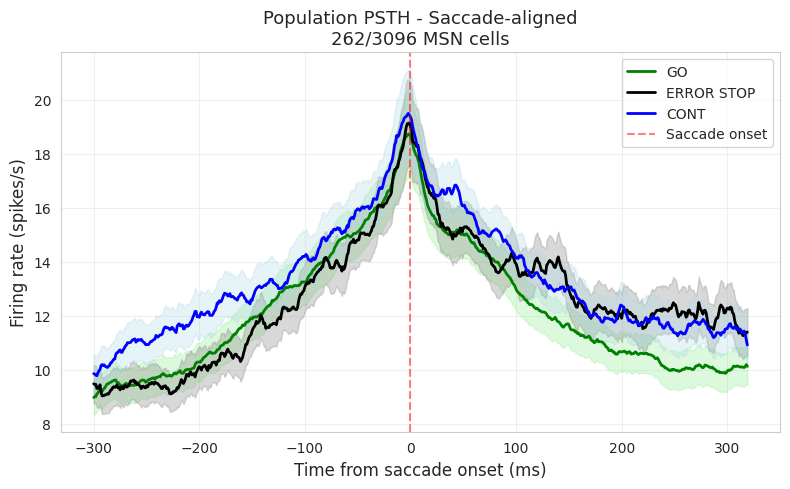

In [17]:
# Extract y_saccade arrays for all trial types and compute mean and SEM
y_saccade_arrays = np.vstack(neuron_stats_df['y_saccade_GO'].values)
y_saccade_stop_arrays = np.vstack(neuron_stats_df['y_saccade_STOP'].values)
y_saccade_cont_arrays = np.vstack(neuron_stats_df['y_saccade_CONT'].values)

mean_y_saccade = np.nanmean(y_saccade_arrays, axis=0)
sem_y_saccade = np.nanstd(y_saccade_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_arrays.shape[0])

mean_y_saccade_stop = np.nanmean(y_saccade_stop_arrays, axis=0)
sem_y_saccade_stop = np.nanstd(y_saccade_stop_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_stop_arrays.shape[0])

mean_y_saccade_cont = np.nanmean(y_saccade_cont_arrays, axis=0)
sem_y_saccade_cont = np.nanstd(y_saccade_cont_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_cont_arrays.shape[0])

# Create x-axis (time points for saccade-aligned data, -100 to +100 ms)
# x_saccade = np.linspace(-300, 300, len(mean_y_saccade))
x_saccade = neuron_stats_df['saccade_time_GO'].iloc[0]

# Plot
fig_saccade, ax_saccade = plt.subplots(figsize=(8, 5))

# GO trials (green)
ax_saccade.plot(x_saccade, mean_y_saccade, color='green', linewidth=2, label='GO')
ax_saccade.fill_between(x_saccade, mean_y_saccade - sem_y_saccade, mean_y_saccade + sem_y_saccade, 
                color='lightgreen', alpha=0.3)

# STOP trials (black)
ax_saccade.plot(x_saccade, mean_y_saccade_stop, color='black', linewidth=2, label='ERROR STOP')
ax_saccade.fill_between(x_saccade, mean_y_saccade_stop - sem_y_saccade_stop, mean_y_saccade_stop + sem_y_saccade_stop, 
                color='gray', alpha=0.3)

# CONT trials (blue)
ax_saccade.plot(x_saccade, mean_y_saccade_cont, color='blue', linewidth=2, label='CONT')
ax_saccade.fill_between(x_saccade, mean_y_saccade_cont - sem_y_saccade_cont, mean_y_saccade_cont + sem_y_saccade_cont, 
                color='lightblue', alpha=0.3)

num_of_msn_cells = cell_df['cell_ID'].nunique()
ax_saccade.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Saccade onset')
ax_saccade.set_xlabel('Time from saccade onset (ms)', fontsize=12)
ax_saccade.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_saccade.set_title(f'Population PSTH - Saccade-aligned\n{neuron_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
ax_saccade.legend()
ax_saccade.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


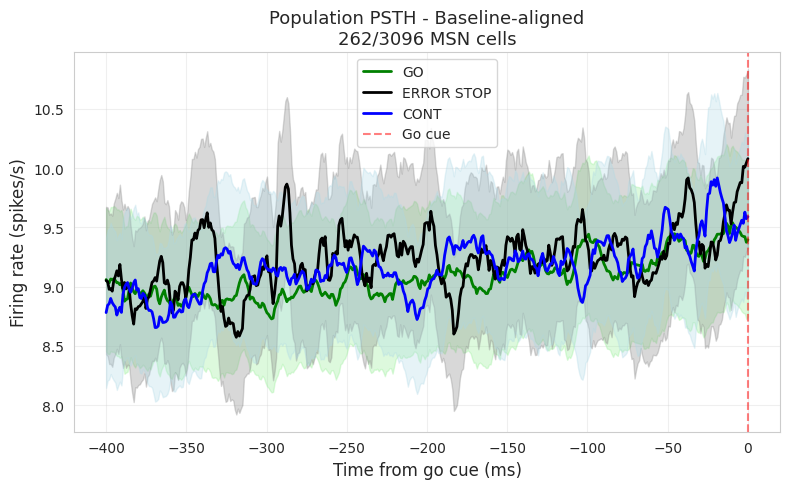

In [18]:
# Extract y_baseline arrays for all trial types and compute mean and SEM
y_baseline_arrays = np.vstack(neuron_stats_df['y_baseline_GO'].values)
y_baseline_stop_arrays = np.vstack(neuron_stats_df['y_baseline_STOP'].values)
y_baseline_cont_arrays = np.vstack(neuron_stats_df['y_baseline_CONT'].values)

mean_y_baseline = np.nanmean(y_baseline_arrays, axis=0)
sem_y_baseline = np.nanstd(y_baseline_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_arrays.shape[0])

mean_y_baseline_stop = np.nanmean(y_baseline_stop_arrays, axis=0)
sem_y_baseline_stop = np.nanstd(y_baseline_stop_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_stop_arrays.shape[0])

mean_y_baseline_cont = np.nanmean(y_baseline_cont_arrays, axis=0)
sem_y_baseline_cont = np.nanstd(y_baseline_cont_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_cont_arrays.shape[0])

# Create x-axis (time points for baseline-aligned data, -400 to 0 ms)
x_baseline = np.linspace(-400, 0, len(mean_y_baseline))

# Plot
fig_baseline, ax_baseline = plt.subplots(figsize=(8, 5))

# GO trials (green)
ax_baseline.plot(x_baseline, mean_y_baseline, color='green', linewidth=2, label='GO')
ax_baseline.fill_between(x_baseline, mean_y_baseline - sem_y_baseline, mean_y_baseline + sem_y_baseline, 
                color='lightgreen', alpha=0.3)

# STOP trials (black)
ax_baseline.plot(x_baseline, mean_y_baseline_stop, color='black', linewidth=2, label='ERROR STOP')
ax_baseline.fill_between(x_baseline, mean_y_baseline_stop - sem_y_baseline_stop, mean_y_baseline_stop + sem_y_baseline_stop, 
                color='gray', alpha=0.3)

# # CONT trials (blue)
ax_baseline.plot(x_baseline, mean_y_baseline_cont, color='blue', linewidth=2, label='CONT')
ax_baseline.fill_between(x_baseline, mean_y_baseline_cont - sem_y_baseline_cont, mean_y_baseline_cont + sem_y_baseline_cont, 
                color='lightblue', alpha=0.3)

ax_baseline.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Go cue')
ax_baseline.set_xlabel('Time from go cue (ms)', fontsize=12)
ax_baseline.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_baseline.set_title(f'Population PSTH - Baseline-aligned\n{neuron_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
ax_baseline.legend()
ax_baseline.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
ssrt_db = pd.read_excel(base_path.parent / f'SSRT_F.xlsx')[['session', 'Left', 'Right']]

ssrt_db['max'] = ssrt_db.max(axis=1, numeric_only=True)
ssrt_db['max'] = ssrt_db['max'].fillna(ssrt_db['max'].max())

def fix_session_name(name):
    if isinstance(name, str):
        return name.replace("'", '')
    return name
ssrt_db['session'] = ssrt_db['session'].apply(fix_session_name)
ssrt_db = ssrt_db.sort_values('session').reset_index(drop=True)
# ssrt_db['Right'].max()

ssd_per_session = cell_df[cell_df['ssd_number'] < 5].groupby('session').apply(
    lambda x: np.nanmean(x['ssd_len']).astype(int)
).reset_index(name='mean_ssd_len').sort_values('session')

ssd_per_session

ssrt_ssd_df = pd.merge(ssrt_db, ssd_per_session, on='session', how='inner')
# ssrt_ssd_df.iloc[ssrt_ssd_df['Right'].isna()]

ssrt_ssd_df['Right'].fillna(np.nanmean(ssrt_ssd_df['Right']), inplace=True)
ssrt_ssd_df['slow_go_thresh'] = (ssrt_ssd_df['Right'] + ssrt_ssd_df['mean_ssd_len']).astype(int)

cell_df = cell_df.merge(
    ssrt_ssd_df[['session', 'slow_go_thresh']], on='session', how='left'
)

print(f"slow_go_thresh value counts:\n{cell_df['slow_go_thresh'].value_counts(dropna=False)}")

# is_slow_go: True for GO trials at or above threshold, False for GO below threshold, NaN for non-GO
cell_df['is_slow_go'] = np.where(
    cell_df['type'] == 'GO',
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    np.nan
)

# is_slow_go: True for CONT trials at or above threshold, False for CONT below threshold
cell_df['is_slow_go'] = np.where(
    (cell_df['type'] == 'CONT') & (cell_df['trial_failed'] == False),
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    cell_df['is_slow_go']  # Keep existing values for non-CONT trials
)

# is_slow_go: for error stop trials
cell_df['is_slow_go'] = np.where(
    (cell_df['type'] == 'STOP') & (cell_df['trial_failed'] == True),
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    cell_df['is_slow_go']  # Keep existing values else
)


# cell_df = cell_df.drop(columns='slow_go_thresh')

print(f"is_slow_go value counts:\n{cell_df['is_slow_go'].value_counts(dropna=False)}")


slow_go_thresh value counts:
slow_go_thresh
212    228329
227    212286
216    165095
228    159953
223    150279
222    146170
214     97759
219     91282
200     77181
230     73462
226     69813
231     67858
229     46475
221     36387
207     35998
248     28201
225     25661
217     25134
244     20706
240     17981
233     17645
220     17459
205     15611
267     15278
259     15094
213     14837
237     13509
209     13414
249     11278
199     10557
246      8839
201      7613
215      1385
235       567
186       100
192        73
Name: count, dtype: int64
is_slow_go value counts:
is_slow_go
1.0    885479
0.0    762116
NaN    291674
Name: count, dtype: int64


In [20]:

def get_neuron_stats_for_fig2(cell_id: int) -> dict:
    """Calculate mean PSTH and SEM for a single neuron in both conditions"""
    try:
        return_dict = {'cell_ID': cell_id}
        c = Cell(
            cell_df[
                (cell_df["cell_ID"] == cell_id) &
                (cell_df['is_slow_go'].isin([True, np.nan]))  # Only include slow GO trials for condition #1
        ])
        for trial_type in ['GO', 'STOP', 'CONT']:
            # Saccade-aligned condition
            success_var = True #False if trial_type == 'STOP' else True
            bin_centers, firing_rate, _ = c.calculate_psth(
                alignment_point="go_cue",
                epok=[0, 600],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
            
            # Baseline-aligned condition
            ss_bin_centers, ss_firing_rate, _ = c.calculate_psth(
                alignment_point="stop_cue",
                epok=[-300, 600],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
        
            return_dict.update({
                f'y_stop_sig_{trial_type}': ss_firing_rate,
                f'stop_sig_time_{trial_type}': ss_bin_centers,
                f'y_go_cue_{trial_type}': firing_rate,
                f'go_cue_time_{trial_type}': bin_centers
            })
        return return_dict
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return None

# Process neurons in parallel
neuron_ids = sorted(list(go_neurons))
# neuron_ids = cell_df['cell_ID'].unique().tolist()
print(f"Processing {len(neuron_ids)} neurons in parallel...")

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(get_neuron_stats_for_fig2, cid): cid for cid in neuron_ids}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(neuron_ids), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)

fig_2_stats_df = pd.DataFrame(neuron_stats).sort_values('cell_ID').reset_index(drop=True)

fig_2_stats_df.head()

Processing 262 neurons in parallel...


Calculating PSTH stats:   0%|          | 0/262 [00:00<?, ?it/s]

,cell_ID,y_stop_sig_GO,stop_sig_time_GO,y_go_cue_GO,go_cue_time_GO,y_stop_sig_STOP,stop_sig_time_STOP,y_go_cue_STOP,go_cue_time_STOP,y_stop_sig_CONT,stop_sig_time_CONT,y_go_cue_CONT,go_cue_time_CONT
0,63,"[15.70125526134177, 16.19120791891616, 17.0651...","[-300, -299, -298, -297, -296, -295, -294, -29...","[15.415031587413031, 15.303548559154642, 14.78...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[27.08694666451389, 25.903880055052518, 24.688...","[-300, -299, -298, -297, -296, -295, -294, -29...","[15.823991721105063, 15.05763400665051, 17.249...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[19.795488587435024, 17.01710911212679, 19.094...","[-300, -299, -298, -297, -296, -295, -294, -29...","[16.60353023117669, 18.51433119280604, 17.3705...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,65,"[1.6650837372611058, 2.860513087186444, 3.1677...","[-300, -299, -298, -297, -296, -295, -294, -29...","[3.2291952608863648, 3.239971245380083, 3.1408...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[2.423604082809403, 2.3054043552668753, 2.1929...","[-300, -299, -298, -297, -296, -295, -294, -29...","[7.172181624838173, 7.135461837022043, 6.89701...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,76,"[13.03061770130647, 12.995849126357182, 13.529...","[-300, -299, -298, -297, -296, -295, -294, -29...","[4.875095009933338, 4.053559178294289, 3.27093...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[15.474354266338239, 14.773014227220408, 14.07...","[-300, -299, -298, -297, -296, -295, -294, -29...","[9.912774402603764, 8.740729964510813, 8.63697...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10.204811356597427, 8.912246542765601, 8.4811...","[-300, -299, -298, -297, -296, -295, -294, -29...","[12.762012211111562, 10.531061394948605, 10.01...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,77,"[25.166634749447994, 25.905552911461157, 25.82...","[-300, -299, -298, -297, -296, -295, -294, -29...","[27.922008833396, 27.844426209215566, 28.25369...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[23.03307627378742, 24.20304598904616, 23.8251...","[-300, -299, -298, -297, -296, -295, -294, -29...","[16.14939540145416, 14.822192004562691, 13.038...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[32.044388587329756, 32.02450195575415, 31.242...","[-300, -299, -298, -297, -296, -295, -294, -29...","[22.187847063157662, 20.25985582395407, 21.695...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,82,"[15.10897931834786, 14.103950969318387, 12.612...","[-300, -299, -298, -297, -296, -295, -294, -29...","[12.569396058300294, 12.009546947338952, 12.33...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[12.132916670099618, 12.378501109909996, 12.06...","[-300, -299, -298, -297, -296, -295, -294, -29...","[12.118413539415414, 13.945225254325392, 16.50...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[6.659083523162836, 7.531805140589167, 7.31597...","[-300, -299, -298, -297, -296, -295, -294, -29...","[11.630796243856729, 11.393212380620309, 13.34...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [21]:
# good_cells = []

# print(fig_2_stats_df.shape)
# for i in range(fig_2_stats_df.shape[0]):
#     for timeing in ['go_cue', 'stop_sig']:
#         a = fig_2_stats_df[f'y_{timeing}_GO'].values[i] is not None 
#         b = fig_2_stats_df[f'y_{timeing}_STOP'].values[i] is not None
#         c = fig_2_stats_df[f'y_{timeing}_CONT'].values[i] is not None
#         if a and b and c:
#             good_cells.append(fig_2_stats_df.iloc[i]['cell_ID'])

# fig_2_stats_df = fig_2_stats_df[fig_2_stats_df['cell_ID'].isin(good_cells)].reset_index(drop=True)

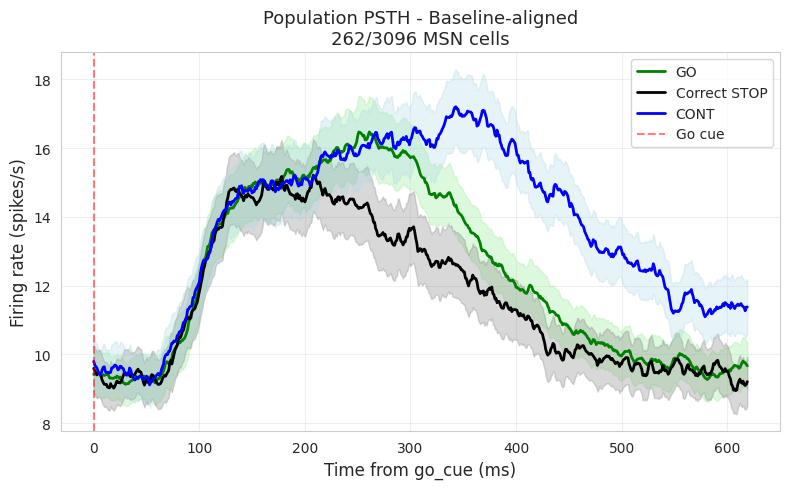

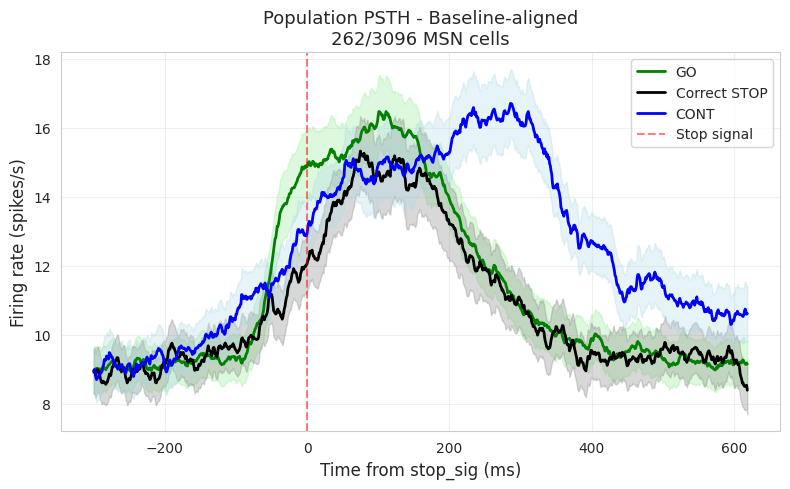

In [22]:
# Extract y_baseline arrays for all trial types and compute mean and SEM
for timeing in ['go_cue', 'stop_sig']:
    y_baseline_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_GO'].values)
    y_baseline_stop_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_STOP'].values)
    y_baseline_cont_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_CONT'].values)

    mean_y_baseline = np.nanmean(y_baseline_arrays, axis=0)
    sem_y_baseline = np.nanstd(y_baseline_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_arrays.shape[0])

    mean_y_baseline_stop = np.nanmean(y_baseline_stop_arrays, axis=0)
    sem_y_baseline_stop = np.nanstd(y_baseline_stop_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_stop_arrays.shape[0])

    mean_y_baseline_cont = np.nanmean(y_baseline_cont_arrays, axis=0)
    sem_y_baseline_cont = np.nanstd(y_baseline_cont_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_cont_arrays.shape[0])

    # Create x-axis (time points for baseline-aligned data, -400 to 0 ms)
    x_baseline = x_saccade = fig_2_stats_df[f'{timeing}_time_GO'].iloc[0]

    # Plot
    fig_baseline, ax_baseline = plt.subplots(figsize=(8, 5))

    # GO trials (green)
    ax_baseline.plot(x_baseline, mean_y_baseline, color='green', linewidth=2, label='GO')
    ax_baseline.fill_between(x_baseline, mean_y_baseline - sem_y_baseline, mean_y_baseline + sem_y_baseline, 
                    color='lightgreen', alpha=0.3)

    # STOP trials (black)
    ax_baseline.plot(x_baseline, mean_y_baseline_stop, color='black', linewidth=2, label='Correct STOP')
    ax_baseline.fill_between(x_baseline, mean_y_baseline_stop - sem_y_baseline_stop, mean_y_baseline_stop + sem_y_baseline_stop, 
                    color='gray', alpha=0.3)

    # # CONT trials (blue)
    ax_baseline.plot(x_baseline, mean_y_baseline_cont, color='blue', linewidth=2, label='CONT')
    ax_baseline.fill_between(x_baseline, mean_y_baseline_cont - sem_y_baseline_cont, mean_y_baseline_cont + sem_y_baseline_cont, 
                    color='lightblue', alpha=0.3)

    ax_baseline.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Go cue' if timeing == 'go_cue' else 'Stop signal')
    ax_baseline.set_xlabel(f'Time from {timeing} (ms)', fontsize=12)
    ax_baseline.set_ylabel('Firing rate (spikes/s)', fontsize=12)
    ax_baseline.set_title(f'Population PSTH - Baseline-aligned\n{fig_2_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
    ax_baseline.legend()
    ax_baseline.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Session-Level Statistics - CORRECTED

In [23]:
# Calculate statistics per session
session_tuning_stats = []

for session_id in summary_df['session_id'].unique():
    session_cells = summary_df[summary_df['session_id'] == session_id]
    n_cells = len(session_cells)
    
    session_tuning_stats.append({
        'session_id': session_id,
        'n_cells': n_cells,
        'n_task_modulated': session_cells['is_task_modulated'].sum(),
        'n_direction_tuned': session_cells['is_direction_tuned'].sum(),
        'n_stop_modulated': session_cells['is_stop_modulated'].sum(),
        'n_cont_modulated': session_cells['is_cont_modulated'].sum(),
        'n_signal_discriminative': session_cells['is_signal_discriminative'].sum(),
        'n_go_vs_signal_different': session_cells['is_go_vs_signal_different'].sum(),
        'pct_task_modulated': session_cells['is_task_modulated'].sum() / n_cells * 100,
        'pct_direction_tuned': session_cells['is_direction_tuned'].sum() / n_cells * 100,
        'pct_stop_modulated': session_cells['is_stop_modulated'].sum() / n_cells * 100,
        'pct_cont_modulated': session_cells['is_cont_modulated'].sum() / n_cells * 100,
        'pct_signal_discriminative': session_cells['is_signal_discriminative'].sum() / n_cells * 100,
        'pct_go_vs_signal_different': session_cells['is_go_vs_signal_different'].sum() / n_cells * 100,
        'mean_baseline_FR': session_cells['baseline_FR'].mean(),
        'mean_go_FR': session_cells['go_FR'].mean(),
        'mean_stop_FR': session_cells['stop_FR'].mean(),
        'mean_cont_FR': session_cells['cont_FR'].mean(),
        'mean_DSI': session_cells['DSI'].abs().mean(),
        'mean_SSI': session_cells['SSI'].abs().mean(),
        'mean_task_MI': session_cells['task_MI'].abs().mean(),
    })

session_tuning_df = pd.DataFrame(session_tuning_stats).sort_values('n_cells', ascending=False)

print("\nSession-Level Tuning Statistics (CORRECTED):")
print("="*80)
display(session_tuning_df)


Session-Level Tuning Statistics (CORRECTED):


,session_id,n_cells,n_task_modulated,n_direction_tuned,n_stop_modulated,n_cont_modulated,n_signal_discriminative,n_go_vs_signal_different,pct_task_modulated,pct_direction_tuned,...,pct_cont_modulated,pct_signal_discriminative,pct_go_vs_signal_different,mean_baseline_FR,mean_go_FR,mean_stop_FR,mean_cont_FR,mean_DSI,mean_SSI,mean_task_MI
34,fi211102a,189,61,27,70,75,24,46,32.275132,14.285714,...,39.682540,12.698413,24.338624,6.853913,7.196118,8.226241,7.953615,0.143554,0.142060,0.145009
21,fi211025a,155,63,41,57,65,35,60,40.645161,26.451613,...,41.935484,22.580645,38.709677,8.427174,9.180412,9.474881,9.340720,0.147180,0.152908,0.132066
50,fi211110a,146,56,17,44,62,14,24,38.356164,11.643836,...,42.465753,9.589041,16.438356,5.878385,5.857395,5.788646,5.596887,0.127003,0.132066,0.148799
17,fi211122a,132,28,9,27,30,16,16,21.212121,6.818182,...,22.727273,12.121212,12.121212,7.181995,7.543333,7.698592,7.569996,0.094239,0.131368,0.106780
1,fi211109a,132,32,14,33,39,15,21,24.242424,10.606061,...,29.545455,11.363636,15.909091,4.421954,4.198579,4.626877,4.601775,0.116390,0.117564,0.112794
8,fi211111a,130,34,6,32,32,8,16,26.153846,4.615385,...,24.615385,6.153846,12.307692,7.457467,6.710363,6.670517,6.693966,0.094042,0.093966,0.104302
16,fi211104a,121,41,18,40,42,22,29,33.884298,14.876033,...,34.710744,18.181818,23.966942,9.315415,9.261046,8.330051,8.887308,0.100666,0.124843,0.106181
31,fi211026a,116,36,13,39,42,10,23,31.034483,11.206897,...,36.206897,8.620690,19.827586,7.818812,7.410168,8.156092,7.881100,0.114231,0.141534,0.136936
2,fi211115a,111,55,45,41,61,25,46,49.549550,40.540541,...,54.954955,22.522523,41.441441,5.444100,6.626405,6.701950,7.065048,0.250863,0.173110,0.221667
20,fi211108a,98,33,23,32,35,12,18,33.673469,23.469388,...,35.714286,12.244898,18.367347,4.003916,3.637448,4.029802,3.736087,0.169287,0.152630,0.142484


## 8. Visualizations

### 8.1 Overall Distribution of Tuning Properties

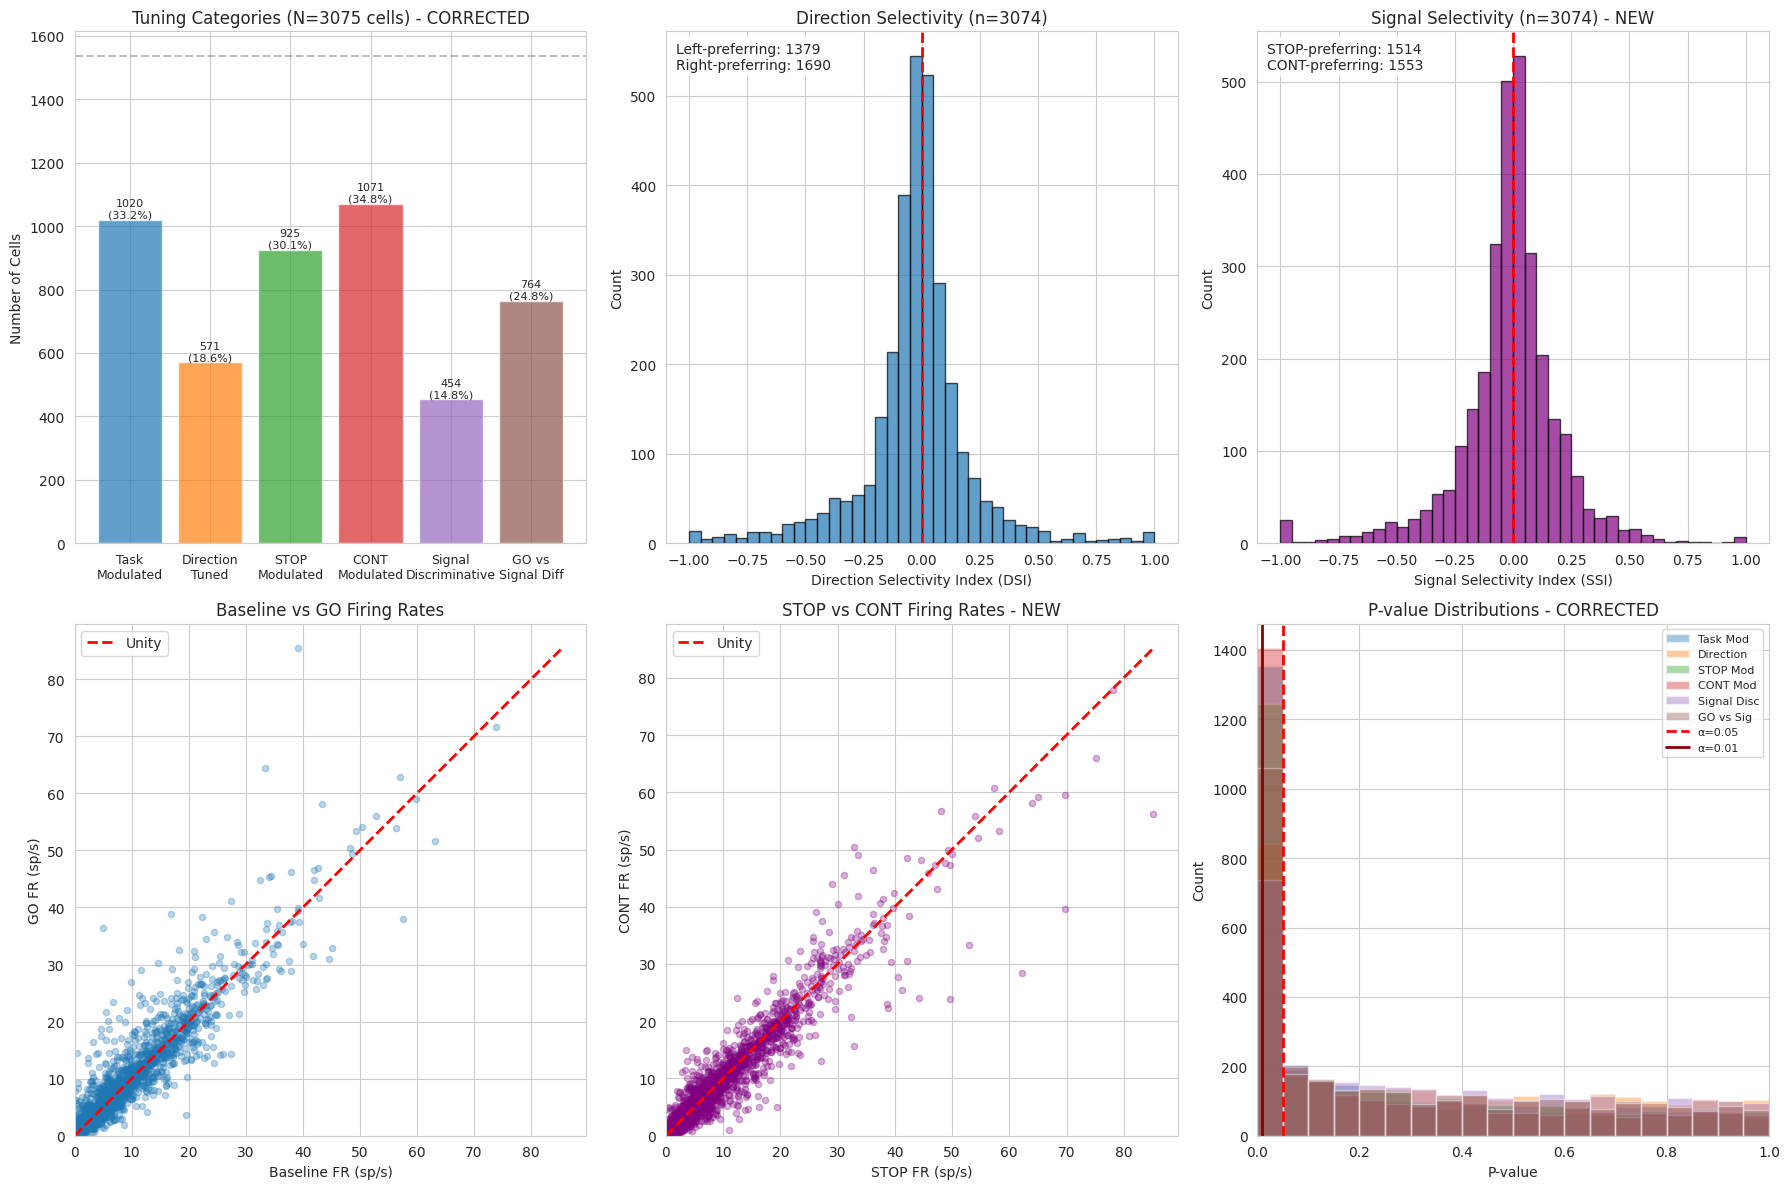

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Tuning category counts
ax = axes[0, 0]
tuning_counts = pd.Series({
    'Task\nModulated': summary_df['is_task_modulated'].sum(),
    'Direction\nTuned': summary_df['is_direction_tuned'].sum(),
    'STOP\nModulated': summary_df['is_stop_modulated'].sum(),
    'CONT\nModulated': summary_df['is_cont_modulated'].sum(),
    'Signal\nDiscriminative': summary_df['is_signal_discriminative'].sum(),
    'GO vs\nSignal Diff': summary_df['is_go_vs_signal_different'].sum()
})
bars = ax.bar(range(len(tuning_counts)), tuning_counts.values, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'], alpha=0.7)
ax.set_xticks(range(len(tuning_counts)))
ax.set_xticklabels(tuning_counts.index, fontsize=9)
ax.set_ylabel('Number of Cells')
ax.set_title(f'Tuning Categories (N={total_cells} cells) - CORRECTED')
ax.axhline(total_cells/2, color='gray', linestyle='--', alpha=0.5)
for bar, count in zip(bars, tuning_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({count/total_cells*100:.1f}%)',
            ha='center', va='bottom', fontsize=8)

# 2. Direction Selectivity Index
ax = axes[0, 1]
dsi_values = summary_df['DSI'].dropna()
ax.hist(dsi_values, bins=40, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Direction Selectivity Index (DSI)')
ax.set_ylabel('Count')
ax.set_title(f'Direction Selectivity (n={len(dsi_values)})')
ax.text(0.02, 0.98, f'Left-preferring: {(dsi_values > 0).sum()}\nRight-preferring: {(dsi_values < 0).sum()}',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Signal Selectivity Index
ax = axes[0, 2]
ssi_values = summary_df['SSI'].dropna()
ax.hist(ssi_values, bins=40, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Signal Selectivity Index (SSI)')
ax.set_ylabel('Count')
ax.set_title(f'Signal Selectivity (n={len(ssi_values)}) - NEW')
ax.text(0.02, 0.98, f'STOP-preferring: {(ssi_values > 0).sum()}\nCONT-preferring: {(ssi_values < 0).sum()}',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Baseline vs GO Firing Rates
ax = axes[1, 0]
baseline_valid = summary_df['baseline_FR'].dropna()
go_valid = summary_df.loc[baseline_valid.index, 'go_FR'].dropna()
baseline_valid = summary_df.loc[go_valid.index, 'baseline_FR']
ax.scatter(baseline_valid, go_valid, alpha=0.3, s=20)
max_val = max(baseline_valid.max(), go_valid.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Unity')
ax.set_xlabel('Baseline FR (sp/s)')
ax.set_ylabel('GO FR (sp/s)')
ax.set_title('Baseline vs GO Firing Rates')
ax.legend()
ax.set_xlim(0, None)
ax.set_ylim(0, None)

# 5. STOP vs CONT Firing Rates
ax = axes[1, 1]
stop_valid = summary_df['stop_FR'].dropna()
cont_valid = summary_df.loc[stop_valid.index, 'cont_FR'].dropna()
stop_valid = summary_df.loc[cont_valid.index, 'stop_FR']
ax.scatter(stop_valid, cont_valid, alpha=0.3, s=20, color='purple')
max_val = max(stop_valid.max(), cont_valid.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Unity')
ax.set_xlabel('STOP FR (sp/s)')
ax.set_ylabel('CONT FR (sp/s)')
ax.set_title('STOP vs CONT Firing Rates - NEW')
ax.legend()
ax.set_xlim(0, None)
ax.set_ylim(0, None)

# 6. P-value distributions
ax = axes[1, 2]
p_cols = ['task_mod_p', 'dir_tuning_p', 'stop_mod_p', 'cont_mod_p', 'signal_disc_p', 'go_vs_signal_p']
labels = ['Task Mod', 'Direction', 'STOP Mod', 'CONT Mod', 'Signal Disc', 'GO vs Sig']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for col, label, color in zip(p_cols, labels, colors):
    ax.hist(summary_df[col].dropna(), bins=20, alpha=0.4, label=label, color=color)
ax.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
ax.axvline(0.01, color='darkred', linestyle='-', linewidth=2, label='α=0.01')
ax.set_xlabel('P-value')
ax.set_ylabel('Count')
ax.set_title('P-value Distributions - CORRECTED')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 8.2 Session-Level Comparisons

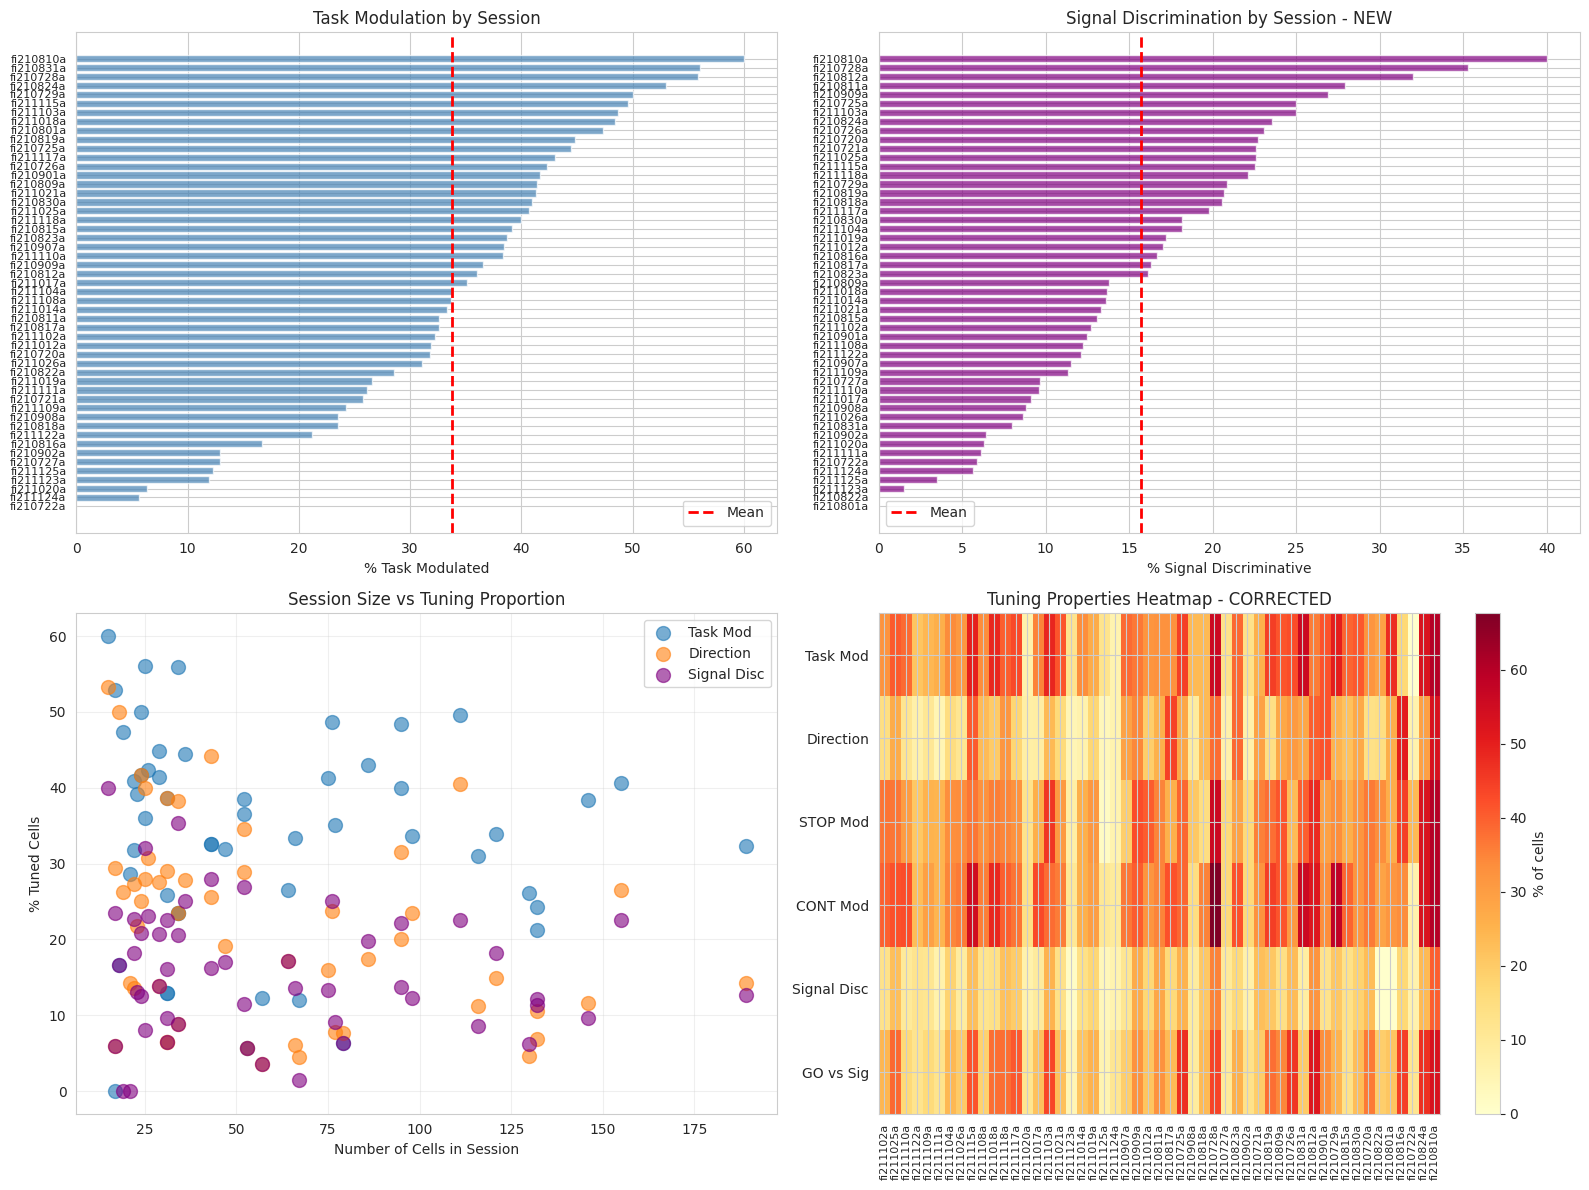

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Percentage of task-modulated cells per session
ax = axes[0, 0]
session_tuning_df_sorted = session_tuning_df.sort_values('pct_task_modulated')
ax.barh(range(len(session_tuning_df_sorted)), session_tuning_df_sorted['pct_task_modulated'],
        color='steelblue', alpha=0.7)
ax.set_yticks(range(len(session_tuning_df_sorted)))
ax.set_yticklabels(session_tuning_df_sorted['session_id'], fontsize=8)
ax.set_xlabel('% Task Modulated')
ax.set_title('Task Modulation by Session')
ax.axvline(session_tuning_df['pct_task_modulated'].mean(), 
           color='red', linestyle='--', linewidth=2, label='Mean')
ax.legend()

# 2. Percentage of signal-discriminative cells per session
ax = axes[0, 1]
session_tuning_df_sorted = session_tuning_df.sort_values('pct_signal_discriminative')
ax.barh(range(len(session_tuning_df_sorted)), session_tuning_df_sorted['pct_signal_discriminative'],
        color='purple', alpha=0.7)
ax.set_yticks(range(len(session_tuning_df_sorted)))
ax.set_yticklabels(session_tuning_df_sorted['session_id'], fontsize=8)
ax.set_xlabel('% Signal Discriminative')
ax.set_title('Signal Discrimination by Session - NEW')
ax.axvline(session_tuning_df['pct_signal_discriminative'].mean(), 
           color='red', linestyle='--', linewidth=2, label='Mean')
ax.legend()

# 3. Number of cells vs percentage tuned
ax = axes[1, 0]
ax.scatter(session_tuning_df['n_cells'], session_tuning_df['pct_task_modulated'], 
          s=100, alpha=0.6, label='Task Mod')
ax.scatter(session_tuning_df['n_cells'], session_tuning_df['pct_direction_tuned'], 
          s=100, alpha=0.6, label='Direction')
ax.scatter(session_tuning_df['n_cells'], session_tuning_df['pct_signal_discriminative'], 
          s=100, alpha=0.6, label='Signal Disc', color='purple')
ax.set_xlabel('Number of Cells in Session')
ax.set_ylabel('% Tuned Cells')
ax.set_title('Session Size vs Tuning Proportion')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Heatmap of tuning properties across sessions - CORRECTED
ax = axes[1, 1]
heatmap_data = session_tuning_df.set_index('session_id')[[
    'pct_task_modulated', 'pct_direction_tuned', 
    'pct_stop_modulated', 'pct_cont_modulated',
    'pct_signal_discriminative', 'pct_go_vs_signal_different'
]].T
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(['Task Mod', 'Direction', 'STOP Mod', 'CONT Mod', 'Signal Disc', 'GO vs Sig'], fontsize=10)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=90, fontsize=8)
ax.set_title('Tuning Properties Heatmap - CORRECTED')
plt.colorbar(im, ax=ax, label='% of cells')

plt.tight_layout()
plt.show()

### 8.3 Sessions with Highest/Lowest Tuning

In [26]:
print("\nSessions with HIGHEST task modulation:")
print("="*80)
display(session_tuning_df.nlargest(5, 'pct_task_modulated')[[
    'session_id', 'n_cells', 'n_task_modulated', 'pct_task_modulated'
]])

print("\nSessions with HIGHEST direction tuning:")
print("="*80)
display(session_tuning_df.nlargest(5, 'pct_direction_tuned')[[
    'session_id', 'n_cells', 'n_direction_tuned', 'pct_direction_tuned'
]])

print("\nSessions with HIGHEST signal discrimination - NEW:")
print("="*80)
display(session_tuning_df.nlargest(5, 'pct_signal_discriminative')[[
    'session_id', 'n_cells', 'n_signal_discriminative', 'pct_signal_discriminative'
]])

print("\nSessions with MOST cells:")
print("="*80)
display(session_tuning_df.nlargest(5, 'n_cells')[[
    'session_id', 'n_cells', 'pct_task_modulated', 'pct_direction_tuned', 'pct_signal_discriminative'
]])


Sessions with HIGHEST task modulation:


,session_id,n_cells,n_task_modulated,pct_task_modulated
41,fi210810a,15,9,60.000000
7,fi210831a,25,14,56.000000
4,fi210728a,34,19,55.882353
26,fi210824a,17,9,52.941176
10,fi210729a,24,12,50.000000



Sessions with HIGHEST direction tuning:


,session_id,n_cells,n_direction_tuned,pct_direction_tuned
41,fi210810a,15,8,53.333333
19,fi210816a,18,9,50.000000
24,fi210817a,43,19,44.186047
38,fi210901a,24,10,41.666667
2,fi211115a,111,45,40.540541



Sessions with HIGHEST signal discrimination - NEW:


,session_id,n_cells,n_signal_discriminative,pct_signal_discriminative
41,fi210810a,15,6,40.000000
4,fi210728a,34,12,35.294118
33,fi210812a,25,8,32.000000
39,fi210811a,43,12,27.906977
47,fi210909a,52,14,26.923077



Sessions with MOST cells:


,session_id,n_cells,pct_task_modulated,pct_direction_tuned,pct_signal_discriminative
34,fi211102a,189,32.275132,14.285714,12.698413
21,fi211025a,155,40.645161,26.451613,22.580645
50,fi211110a,146,38.356164,11.643836,9.589041
17,fi211122a,132,21.212121,6.818182,12.121212
1,fi211109a,132,24.242424,10.606061,11.363636


## Two-Way ANOVA: Task × Direction and Signal × Direction (CORRECTED)
Defines interaction tests matching the single-session notebook, using the shared WINDOWS config.


In [27]:

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

def two_way_anova_task_direction(cell, alpha=0.05, verbose=False):
    """
    Two-way ANOVA to test:
    1. Main effect of task (Baseline vs GO)
    2. Main effect of direction (Left vs Right)
    3. Interaction: Task × Direction
    """
    baseline_left = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=180)
    baseline_right = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=0)
    go_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
    go_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)

    if any(len(x) < 2 for x in [baseline_left, baseline_right, go_left, go_right]):
        return {'cell_id': cell.cell_id, 'sufficient_data': False, 'error': 'Insufficient trials'}

    data_list = []
    for rate in baseline_left:
        data_list.append({'firing_rate': rate, 'task': 'Baseline', 'direction': 'Left'})
    for rate in baseline_right:
        data_list.append({'firing_rate': rate, 'task': 'Baseline', 'direction': 'Right'})
    for rate in go_left:
        data_list.append({'firing_rate': rate, 'task': 'GO', 'direction': 'Left'})
    for rate in go_right:
        data_list.append({'firing_rate': rate, 'task': 'GO', 'direction': 'Right'})

    df_anova = pd.DataFrame(data_list)
    model = ols('firing_rate ~ C(task) + C(direction) + C(task):C(direction)', data=df_anova).fit()
    anova_table = anova_lm(model, typ=2)

    return {
        'cell_id': cell.cell_id,
        'sufficient_data': True,
        'task_effect': {
            'F': anova_table.loc['C(task)', 'F'],
            'p': anova_table.loc['C(task)', 'PR(>F)'],
            'significant': anova_table.loc['C(task)', 'PR(>F)'] < alpha
        },
        'direction_effect': {
            'F': anova_table.loc['C(direction)', 'F'],
            'p': anova_table.loc['C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(direction)', 'PR(>F)'] < alpha
        },
        'interaction_effect': {
            'F': anova_table.loc['C(task):C(direction)', 'F'],
            'p': anova_table.loc['C(task):C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(task):C(direction)', 'PR(>F)'] < alpha
        },
    }

def two_way_anova_signal_direction(cell, signal_type='STOP', comparison='baseline', alpha=0.05, verbose=False):
    """
    Two-way ANOVA to test:
    1. Main effect of signal vs comparison period (Baseline or GO)
    2. Main effect of direction (Left vs Right)
    3. Interaction: Signal × Direction
    """
    if comparison == 'baseline':
        comp_left = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=180)
        comp_right = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=0)
        comp_label = 'Baseline'
    elif comparison == 'GO':
        comp_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
        comp_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)
        comp_label = 'GO'
    else:
        raise ValueError(f"Unknown comparison: {comparison}")

    signal_left = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type=signal_type, direction=180)
    signal_right = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type=signal_type, direction=0)

    if any(len(x) < 2 for x in [comp_left, comp_right, signal_left, signal_right]):
        return {
            'cell_id': cell.cell_id,
            'signal_type': signal_type,
            'comparison': comparison,
            'sufficient_data': False,
            'error': 'Insufficient trials in one or more conditions',
        }

    data_list = []
    for rate in comp_left:
        data_list.append({'firing_rate': rate, 'period': comp_label, 'direction': 'Left'})
    for rate in comp_right:
        data_list.append({'firing_rate': rate, 'period': comp_label, 'direction': 'Right'})
    for rate in signal_left:
        data_list.append({'firing_rate': rate, 'period': signal_type, 'direction': 'Left'})
    for rate in signal_right:
        data_list.append({'firing_rate': rate, 'period': signal_type, 'direction': 'Right'})

    df_anova = pd.DataFrame(data_list)
    model = ols('firing_rate ~ C(period) + C(direction) + C(period):C(direction)', data=df_anova).fit()
    anova_table = anova_lm(model, typ=2)

    return {
        'cell_id': cell.cell_id,
        'signal_type': signal_type,
        'comparison': comparison,
        'sufficient_data': True,
        'period_effect': {
            'F': anova_table.loc['C(period)', 'F'],
            'p': anova_table.loc['C(period)', 'PR(>F)'],
            'significant': anova_table.loc['C(period)', 'PR(>F)'] < alpha
        },
        'direction_effect': {
            'F': anova_table.loc['C(direction)', 'F'],
            'p': anova_table.loc['C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(direction)', 'PR(>F)'] < alpha
        },
        'interaction_effect': {
            'F': anova_table.loc['C(period):C(direction)', 'F'],
            'p': anova_table.loc['C(period):C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(period):C(direction)', 'PR(>F)'] < alpha
        },
    }

print("✓ Two-way ANOVA helpers defined")


✓ Two-way ANOVA helpers defined


## Run Two-Way ANOVAs Across All Cells
Adds task×direction and signal×direction interaction metrics for every cell before saving outputs.


In [28]:

# Run two-way ANOVAs across all sessions
task_dir_results = []
stop_baseline_results = []
stop_go_results = []
cont_baseline_results = []
cont_go_results = []

print(f"Running two-way ANOVAs on {len(session_ids)} sessions...")

for session_id in tqdm(session_ids, desc='Two-way ANOVA sessions'):
    session_data = cell_df[cell_df['trial_session'] == session_id]
    session = Session(session_data, verbose=False)
    
    if len(session.cell_ids) > 15 :
        continue

    for cell_id in session.cell_ids:
        cell = session.get_cell(cell_id)
        td_res = two_way_anova_task_direction(cell, verbose=False)
        td_res['session_id'] = session_id
        task_dir_results.append(td_res)

        for signal_type, comparison, bucket in [
            ('STOP', 'baseline', stop_baseline_results),
            ('STOP', 'GO', stop_go_results),
            ('CONT', 'baseline', cont_baseline_results),
            ('CONT', 'GO', cont_go_results),
        ]:
            res = two_way_anova_signal_direction(cell, signal_type=signal_type, comparison=comparison, verbose=False)
            res['session_id'] = session_id
            bucket.append(res)

# Build DataFrames (filtering to cells with sufficient data)
task_dir_df = pd.DataFrame([
    {
        'session_id': res['session_id'],
        'cell_id': res['cell_id'],
        'task_effect_significant': res['task_effect']['significant'],
        'direction_effect_significant': res['direction_effect']['significant'],
        'interaction_significant': res['interaction_effect']['significant'],
        'task_p': res['task_effect']['p'],
        'direction_p': res['direction_effect']['p'],
        'interaction_p': res['interaction_effect']['p'],
    }
    for res in task_dir_results
    if res.get('sufficient_data')
])

def _signal_df(rows):
    records = []
    for res in rows:
        if not res.get('sufficient_data'):
            continue
        records.append({
            'session_id': res['session_id'],
            'cell_id': res['cell_id'],
            'interaction_significant': res['interaction_effect']['significant'],
            'interaction_p': res['interaction_effect']['p'],
        })
    return pd.DataFrame(records)

stop_baseline_df = _signal_df(stop_baseline_results).rename(columns={
    'interaction_significant': 'stop_baseline_interaction',
    'interaction_p': 'stop_baseline_interaction_p',
})
stop_go_df = _signal_df(stop_go_results).rename(columns={
    'interaction_significant': 'stop_go_interaction',
    'interaction_p': 'stop_go_interaction_p',
})
cont_baseline_df = _signal_df(cont_baseline_results).rename(columns={
    'interaction_significant': 'cont_baseline_interaction',
    'interaction_p': 'cont_baseline_interaction_p',
})
cont_go_df = _signal_df(cont_go_results).rename(columns={
    'interaction_significant': 'cont_go_interaction',
    'interaction_p': 'cont_go_interaction_p',
})

print(f"\n✓ Two-way ANOVA tables built ({len(task_dir_df)} cells with sufficient data)")

# Merge into summary_df for saving
summary_df = summary_df.merge(task_dir_df, on=['session_id', 'cell_id'], how='left')
summary_df = summary_df.merge(stop_baseline_df, on=['session_id', 'cell_id'], how='left')
summary_df = summary_df.merge(stop_go_df, on=['session_id', 'cell_id'], how='left')
summary_df = summary_df.merge(cont_baseline_df, on=['session_id', 'cell_id'], how='left')
summary_df = summary_df.merge(cont_go_df, on=['session_id', 'cell_id'], how='left')

# Quick interaction summary
print('\nInteraction summary (any cells meeting criteria):')
for label, col in [
    ('Task × Direction', 'interaction_significant'),
    ('STOP vs Baseline × Direction', 'stop_baseline_interaction'),
    ('STOP vs GO × Direction', 'stop_go_interaction'),
    ('CONT vs Baseline × Direction', 'cont_baseline_interaction'),
    ('CONT vs GO × Direction', 'cont_go_interaction'),
]:
    if col in summary_df:
        total = summary_df[col].fillna(False).sum()
        print(f"  {label}: {int(total)} cells")

print('✓ Two-way ANOVA results merged into summary_df')


Running two-way ANOVAs on 61 sessions...


Two-way ANOVA sessions:   0%|          | 0/61 [00:00<?, ?it/s]


✓ Two-way ANOVA tables built (36 cells with sufficient data)

Interaction summary (any cells meeting criteria):
  Task × Direction: 7 cells
  STOP vs Baseline × Direction: 2 cells
  STOP vs GO × Direction: 5 cells
  CONT vs Baseline × Direction: 5 cells
  CONT vs GO × Direction: 4 cells
✓ Two-way ANOVA results merged into summary_df


## 9. Save Results - CORRECTED

In [29]:
# Create output directory
output_path = Path.cwd().parent / 'data' / 'tuning_analysis_v2'
output_path.mkdir(exist_ok=True)

# Save overall summary
csv_file = output_path / f'tuning_summary_all_sessions_{monkey}.csv'
summary_df.to_csv(csv_file, index=False)
print(f"✓ Saved overall summary to: {csv_file}")

# Save session-level statistics
session_csv = output_path / f'session_tuning_stats_{monkey}.csv'
session_tuning_df.to_csv(session_csv, index=False)
print(f"✓ Saved session statistics to: {session_csv}")

# Save full results as pickle
pkl_file = output_path / f'tuning_full_results_all_sessions_{monkey}.pkl'
pd.to_pickle(all_results, pkl_file)
print(f"✓ Saved full results to: {pkl_file}")

# Save individual session files
print(f"\nSaving individual session files...")
for session_id in tqdm(summary_df['session_id'].unique(), desc="Saving sessions"):
    session_data = summary_df[summary_df['session_id'] == session_id]
    session_file = output_path / f'tuning_summary_{session_id}.csv'
    session_data.to_csv(session_file, index=False)

print(f"\n✓ All results saved to: {output_path}")
print(f"\nNOTE: Results saved with CORRECTED alignment (STOP/CONT to stop_cue)")

✓ Saved overall summary to: /home/barak/Projects/population-analysis/data/tuning_analysis_v2/tuning_summary_all_sessions_fiona.csv
✓ Saved session statistics to: /home/barak/Projects/population-analysis/data/tuning_analysis_v2/session_tuning_stats_fiona.csv
✓ Saved full results to: /home/barak/Projects/population-analysis/data/tuning_analysis_v2/tuning_full_results_all_sessions_fiona.pkl

Saving individual session files...


Saving sessions:   0%|          | 0/51 [00:00<?, ?it/s]


✓ All results saved to: /home/barak/Projects/population-analysis/data/tuning_analysis_v2

NOTE: Results saved with CORRECTED alignment (STOP/CONT to stop_cue)


## 10. Statistical Tests Across Sessions

In [30]:
print("\n" + "="*80)
print("STATISTICAL TESTS - CORRECTED")
print("="*80)

# Test: Do sessions differ in proportion of task-modulated cells?
print("\n1. Variability in task modulation across sessions:")
print("-"*80)
print(f"Mean: {session_tuning_df['pct_task_modulated'].mean():.1f}%")
print(f"Std:  {session_tuning_df['pct_task_modulated'].std():.1f}%")
print(f"Range: {session_tuning_df['pct_task_modulated'].min():.1f}% - {session_tuning_df['pct_task_modulated'].max():.1f}%")

# Test: Do sessions differ in proportion of direction-tuned cells?
print("\n2. Variability in direction tuning across sessions:")
print("-"*80)
print(f"Mean: {session_tuning_df['pct_direction_tuned'].mean():.1f}%")
print(f"Std:  {session_tuning_df['pct_direction_tuned'].std():.1f}%")
print(f"Range: {session_tuning_df['pct_direction_tuned'].min():.1f}% - {session_tuning_df['pct_direction_tuned'].max():.1f}%")

# Test: Do sessions differ in proportion of signal-discriminative cells? (NEW)
print("\n3. Variability in signal discrimination across sessions - NEW:")
print("-"*80)
print(f"Mean: {session_tuning_df['pct_signal_discriminative'].mean():.1f}%")
print(f"Std:  {session_tuning_df['pct_signal_discriminative'].std():.1f}%")
print(f"Range: {session_tuning_df['pct_signal_discriminative'].min():.1f}% - {session_tuning_df['pct_signal_discriminative'].max():.1f}%")

# Test: Correlation between session size and tuning proportion
from scipy.stats import pearsonr, spearmanr

print("\n4. Correlation: Session size vs tuning proportions:")
print("-"*80)

r_task, p_task = pearsonr(session_tuning_df['n_cells'], session_tuning_df['pct_task_modulated'])
print(f"Task modulation: r={r_task:.3f}, p={p_task:.4f}")

r_dir, p_dir = pearsonr(session_tuning_df['n_cells'], session_tuning_df['pct_direction_tuned'])
print(f"Direction tuning: r={r_dir:.3f}, p={p_dir:.4f}")

r_sig, p_sig = pearsonr(session_tuning_df['n_cells'], session_tuning_df['pct_signal_discriminative'])
print(f"Signal discrimination: r={r_sig:.3f}, p={p_sig:.4f}")

# Test: Are mean firing rates different between tuned and non-tuned cells?
print("\n5. Firing rates: Tuned vs Non-tuned cells:")
print("-"*80)

task_mod_FR = summary_df[summary_df['is_task_modulated']]['baseline_FR'].dropna()
not_task_mod_FR = summary_df[~summary_df['is_task_modulated']]['baseline_FR'].dropna()

if len(task_mod_FR) > 0 and len(not_task_mod_FR) > 0:
    t_stat, p_val = stats.ttest_ind(task_mod_FR, not_task_mod_FR)
    print(f"Task-modulated: {task_mod_FR.mean():.2f} ± {task_mod_FR.std():.2f} sp/s")
    print(f"Not modulated:  {not_task_mod_FR.mean():.2f} ± {not_task_mod_FR.std():.2f} sp/s")
    print(f"t-test: t={t_stat:.3f}, p={p_val:.4f}")

dir_tuned_FR = summary_df[summary_df['is_direction_tuned']]['baseline_FR'].dropna()
not_dir_tuned_FR = summary_df[~summary_df['is_direction_tuned']]['baseline_FR'].dropna()

if len(dir_tuned_FR) > 0 and len(not_dir_tuned_FR) > 0:
    t_stat, p_val = stats.ttest_ind(dir_tuned_FR, not_dir_tuned_FR)
    print(f"\nDirection-tuned: {dir_tuned_FR.mean():.2f} ± {dir_tuned_FR.std():.2f} sp/s")
    print(f"Not tuned:       {not_dir_tuned_FR.mean():.2f} ± {not_dir_tuned_FR.std():.2f} sp/s")
    print(f"t-test: t={t_stat:.3f}, p={p_val:.4f}")

sig_disc_FR = summary_df[summary_df['is_signal_discriminative']]['baseline_FR'].dropna()
not_sig_disc_FR = summary_df[~summary_df['is_signal_discriminative']]['baseline_FR'].dropna()

if len(sig_disc_FR) > 0 and len(not_sig_disc_FR) > 0:
    t_stat, p_val = stats.ttest_ind(sig_disc_FR, not_sig_disc_FR)
    print(f"\nSignal-discriminative: {sig_disc_FR.mean():.2f} ± {sig_disc_FR.std():.2f} sp/s")
    print(f"Not discriminative:    {not_sig_disc_FR.mean():.2f} ± {not_sig_disc_FR.std():.2f} sp/s")
    print(f"t-test: t={t_stat:.3f}, p={p_val:.4f}")


STATISTICAL TESTS - CORRECTED

1. Variability in task modulation across sessions:
--------------------------------------------------------------------------------
Mean: 33.8%
Std:  13.8%
Range: 0.0% - 60.0%

2. Variability in direction tuning across sessions:
--------------------------------------------------------------------------------
Mean: 21.7%
Std:  12.9%
Range: 3.5% - 53.3%

3. Variability in signal discrimination across sessions - NEW:
--------------------------------------------------------------------------------
Mean: 15.7%
Std:  8.8%
Range: 0.0% - 40.0%

4. Correlation: Session size vs tuning proportions:
--------------------------------------------------------------------------------
Task modulation: r=-0.063, p=0.6585
Direction tuning: r=-0.343, p=0.0138
Signal discrimination: r=-0.156, p=0.2737

5. Firing rates: Tuned vs Non-tuned cells:
--------------------------------------------------------------------------------
Task-modulated: 8.30 ± 8.59 sp/s
Not modulated:  5.9

## 11. Summary Report

In [31]:
# Generate summary report
report = f"""
{'='*80}
MULTI-SESSION TUNING ANALYSIS SUMMARY REPORT - CORRECTED
{'='*80}

Dataset: {monkey.capitalize()}
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

IMPORTANT: This analysis uses CORRECTED alignment:
- STOP/CONT trials aligned to stop_cue (not go_cue)
- Measures actual signal responses, not initial GO responses

{'='*80}
DATASET OVERVIEW
{'='*80}
Total sessions analyzed: {summary_df['session_id'].nunique()}
Total cells analyzed: {len(summary_df)}
Mean cells per session: {session_tuning_df['n_cells'].mean():.1f} (range: {session_tuning_df['n_cells'].min()}-{session_tuning_df['n_cells'].max()})

{'='*80}
OVERALL TUNING STATISTICS (CORRECTED)
{'='*80}
Task modulated (GO):       {summary_df['is_task_modulated'].sum():4d} / {len(summary_df)} ({summary_df['is_task_modulated'].sum()/len(summary_df)*100:5.1f}%)
Direction tuned:           {summary_df['is_direction_tuned'].sum():4d} / {len(summary_df)} ({summary_df['is_direction_tuned'].sum()/len(summary_df)*100:5.1f}%)
STOP modulated:            {summary_df['is_stop_modulated'].sum():4d} / {len(summary_df)} ({summary_df['is_stop_modulated'].sum()/len(summary_df)*100:5.1f}%)
CONT modulated:            {summary_df['is_cont_modulated'].sum():4d} / {len(summary_df)} ({summary_df['is_cont_modulated'].sum()/len(summary_df)*100:5.1f}%)
Signal discriminative:     {summary_df['is_signal_discriminative'].sum():4d} / {len(summary_df)} ({summary_df['is_signal_discriminative'].sum()/len(summary_df)*100:5.1f}%)
GO vs Signal different:    {summary_df['is_go_vs_signal_different'].sum():4d} / {len(summary_df)} ({summary_df['is_go_vs_signal_different'].sum()/len(summary_df)*100:5.1f}%)

{'='*80}
DIRECTION PREFERENCES (among direction-tuned cells)
{'='*80}
"""

dir_tuned_cells = summary_df[summary_df['is_direction_tuned']]
if len(dir_tuned_cells) > 0:
    dir_counts = dir_tuned_cells['preferred_direction'].value_counts()
    for direction, count in dir_counts.items():
        report += f"{direction.capitalize():10s}: {count:4d} ({count/len(dir_tuned_cells)*100:5.1f}%)\n"
else:
    report += "No direction-tuned cells found\n"

report += f"""
{'='*80}
SIGNAL PREFERENCES (among signal-discriminative cells) - NEW
{'='*80}
"""

sig_disc_cells = summary_df[summary_df['is_signal_discriminative']]
if len(sig_disc_cells) > 0:
    sig_counts = sig_disc_cells['preferred_signal'].value_counts()
    for signal, count in sig_counts.items():
        report += f"{signal:10s}: {count:4d} ({count/len(sig_disc_cells)*100:5.1f}%)\n"
else:
    report += "No signal-discriminative cells found\n"

report += f"""
{'='*80}
SESSION-LEVEL VARIABILITY
{'='*80}
Task modulation:       {session_tuning_df['pct_task_modulated'].mean():.1f}% ± {session_tuning_df['pct_task_modulated'].std():.1f}%
Direction tuning:      {session_tuning_df['pct_direction_tuned'].mean():.1f}% ± {session_tuning_df['pct_direction_tuned'].std():.1f}%
Signal discrimination: {session_tuning_df['pct_signal_discriminative'].mean():.1f}% ± {session_tuning_df['pct_signal_discriminative'].std():.1f}%

{'='*80}
TOP SESSIONS (by number of cells)
{'='*80}
"""

top_sessions = session_tuning_df.nlargest(5, 'n_cells')
for _, row in top_sessions.iterrows():
    report += f"{row['session_id']:15s}: {int(row['n_cells']):3d} cells, "
    report += f"Task: {row['pct_task_modulated']:5.1f}%, Dir: {row['pct_direction_tuned']:5.1f}%, Sig: {row['pct_signal_discriminative']:5.1f}%\n"

report += f"""
{'='*80}
KEY CORRECTIONS IN THIS ANALYSIS
{'='*80}
1. STOP/CONT trials aligned to stop_cue (not go_cue)
2. New measures: STOP modulation, CONT modulation, Signal discrimination
3. Signal Selectivity Index (SSI) added
4. 6 tests instead of 5 (Bonferroni correction adjusted)

{'='*80}
FILES SAVED
{'='*80}
Overall summary:     tuning_summary_all_sessions_{monkey}.csv
Session statistics:  session_tuning_stats_{monkey}.csv
Full results:        tuning_full_results_all_sessions_{monkey}.pkl
Individual sessions: tuning_summary_[session_id].csv (one per session)

Location: {output_path}
{'='*80}
"""

print(report)

# Save report
report_file = output_path / f'tuning_analysis_report_{monkey}.txt'
with open(report_file, 'w') as f:
    f.write(report)
print(f"\n✓ Report saved to: {report_file}")


MULTI-SESSION TUNING ANALYSIS SUMMARY REPORT - CORRECTED

Dataset: Fiona
Date: 2026-02-15 14:10:14

IMPORTANT: This analysis uses CORRECTED alignment:
- STOP/CONT trials aligned to stop_cue (not go_cue)
- Measures actual signal responses, not initial GO responses

DATASET OVERVIEW
Total sessions analyzed: 51
Total cells analyzed: 3075
Mean cells per session: 60.3 (range: 15-189)

OVERALL TUNING STATISTICS (CORRECTED)
Task modulated (GO):       1020 / 3075 ( 33.2%)
Direction tuned:            571 / 3075 ( 18.6%)
STOP modulated:             925 / 3075 ( 30.1%)
CONT modulated:            1071 / 3075 ( 34.8%)
Signal discriminative:      454 / 3075 ( 14.8%)
GO vs Signal different:     764 / 3075 ( 24.8%)

DIRECTION PREFERENCES (among direction-tuned cells)
Right     :  386 ( 67.6%)
Left      :  185 ( 32.4%)

SIGNAL PREFERENCES (among signal-discriminative cells) - NEW
STOP      :  232 ( 51.1%)
CONT      :  222 ( 48.9%)

SESSION-LEVEL VARIABILITY
Task modulation:       33.8% ± 13.8%
Directi

## Enhanced Visualizations
Session-level heatmaps, effect-size distributions, GO vs signal scatter, interaction maps, embeddings, and optional window sweeps.

### Session Heatmap of Tuning Rates
Heatmap of tuning percentages by session across properties (includes interactions when available).

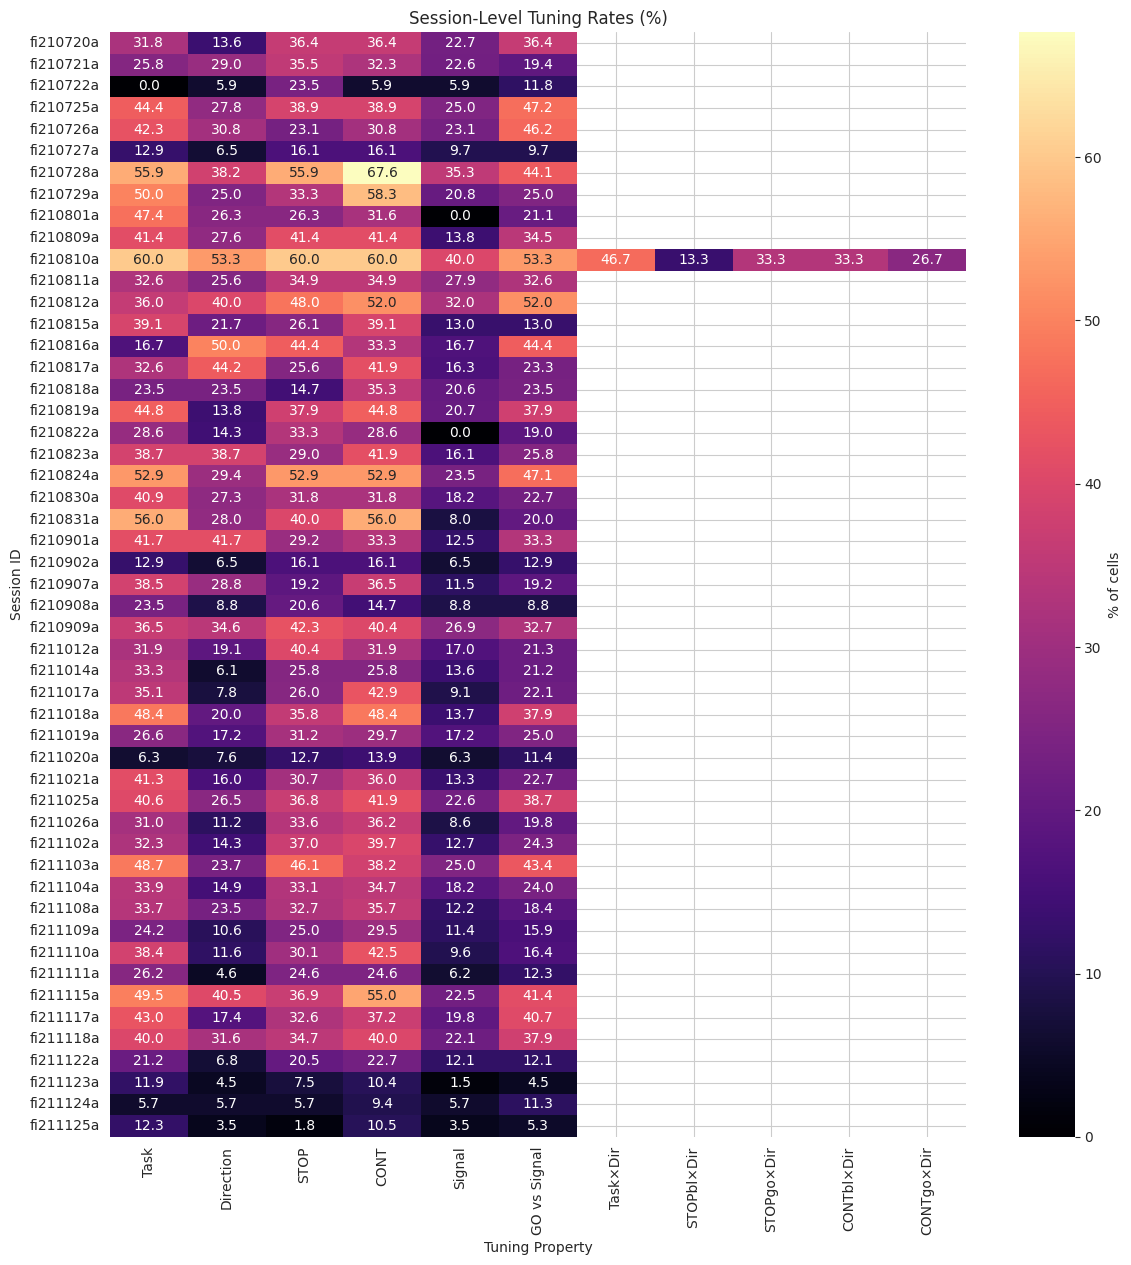

In [32]:

try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    sns = None
import matplotlib.pyplot as plt

props = {
    'Task': 'is_task_modulated',
    'Direction': 'is_direction_tuned',
    'STOP': 'is_stop_modulated',
    'CONT': 'is_cont_modulated',
    'Signal': 'is_signal_discriminative',
    'GO vs Signal': 'is_go_vs_signal_different',
}
# Add interactions if present
for label, col in [
    ('Task×Dir', 'interaction_significant'),
    ('STOPbl×Dir', 'stop_baseline_interaction'),
    ('STOPgo×Dir', 'stop_go_interaction'),
    ('CONTbl×Dir', 'cont_baseline_interaction'),
    ('CONTgo×Dir', 'cont_go_interaction'),
]:
    if col in summary_df:
        props[label] = col

cols_present = [c for c in props.values() if c in summary_df]
if not cols_present:
    print('No tuning columns available for heatmap.')
else:
    heat_df = summary_df.groupby('session_id')[cols_present].mean() * 100
    # Ensure numeric
    heat_df = heat_df.apply(pd.to_numeric, errors='coerce')
    heat_df = heat_df.rename(columns={v: k for k, v in props.items() if v in heat_df.columns})
    if heat_df.empty:
        print('No data available for heatmap after filtering.')
    else:
        plt.figure(figsize=(12, max(6, 0.25 * len(heat_df))))
        if sns:
            sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='magma', cbar_kws={'label': '% of cells'})
        else:
            plt.imshow(heat_df.values, aspect='auto', cmap='magma')
            plt.xticks(range(len(heat_df.columns)), heat_df.columns, rotation=45, ha='right')
            plt.yticks(range(len(heat_df.index)), heat_df.index)
            for (i, j), val in np.ndenumerate(heat_df.values):
                plt.text(j, i, f"{val:.1f}", ha='center', va='center', color='white', fontsize=8)
        plt.title('Session-Level Tuning Rates (%)')
        plt.xlabel('Tuning Property')
        plt.ylabel('Session ID')
        plt.tight_layout()
        plt.show()


### Effect Size Distributions
Violin/box plots for Cohen's d, eta-squared proxies (DSI/SSI) split by significance.

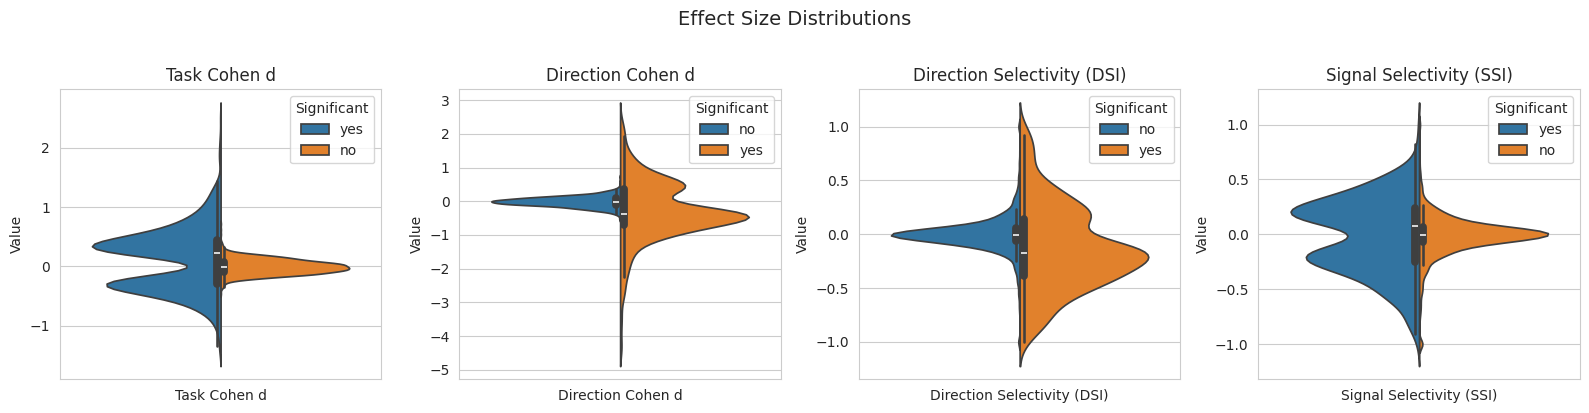

In [33]:

import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    sns = None

effect_cols = {
    'Task Cohen d': ('cohens_d_task', 'is_task_modulated'),
    'Direction Cohen d': ('cohens_d_direction', 'is_direction_tuned'),
    'Direction Selectivity (DSI)': ('DSI', 'is_direction_tuned'),
    'Signal Selectivity (SSI)': ('SSI', 'is_signal_discriminative'),
}
long_rows = []
for label, (col, flag) in effect_cols.items():
    if col not in summary_df:
        continue
    for val, sig in zip(summary_df[col], summary_df[flag]):
        if pd.isna(val):
            continue
        long_rows.append({'metric': label, 'value': val, 'significant': 'yes' if sig else 'no'})
effect_long = pd.DataFrame(long_rows)
if effect_long.empty:
    print('No effect-size data available for plotting.')
else:
    fig, axes = plt.subplots(1, len(effect_long['metric'].unique()), figsize=(4*len(effect_long['metric'].unique()), 4), sharey=False)
    if len(effect_long['metric'].unique()) == 1:
        axes = [axes]
    for ax, metric in zip(axes, effect_long['metric'].unique()):
        subset = effect_long[effect_long['metric'] == metric]
        if sns:
            sns.violinplot(data=subset, x='metric', y='value', hue='significant', split=True, ax=ax, inner='box')
        else:
            subset.boxplot(by='significant', column='value', ax=ax)
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.set_ylabel('Value')
        ax.legend(title='Significant', loc='best')
    fig.suptitle('Effect Size Distributions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### GO vs Signal Scatter
Scatter plots of GO vs STOP/CONT firing rates with significance coloring.

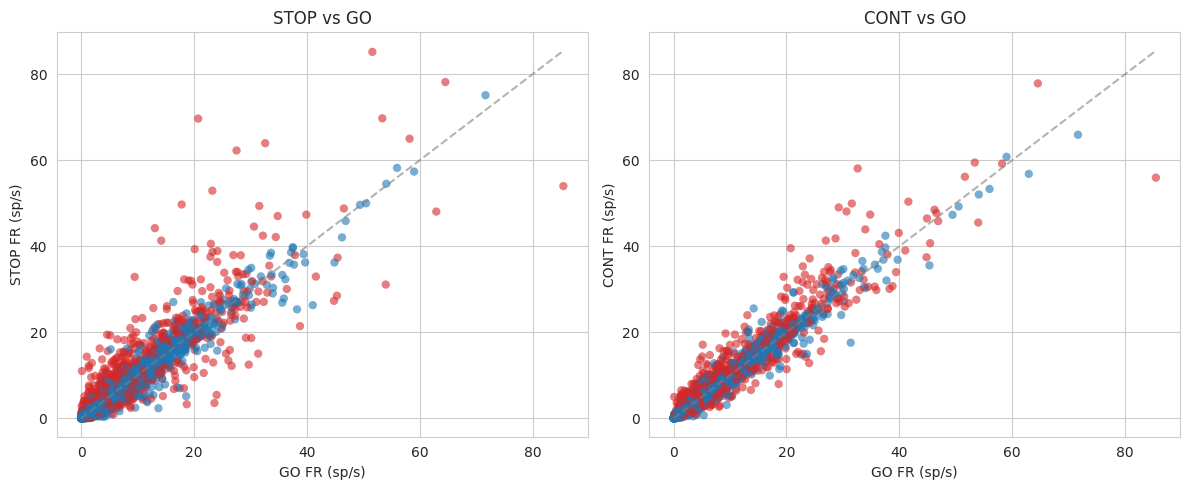

In [34]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_sets = [
    ('STOP vs GO', 'stop_FR', 'is_stop_modulated'),
    ('CONT vs GO', 'cont_FR', 'is_cont_modulated'),
]
for ax, (title, col, flag) in zip(axes, scatter_sets):
    if col not in summary_df:
        ax.text(0.5, 0.5, f'Missing column {col}', ha='center')
        continue
    x = summary_df['go_FR']
    y = summary_df[col]
    colors = summary_df[flag].map({True: '#d62728', False: '#1f77b4'}) if flag in summary_df else '#1f77b4'
    ax.scatter(x, y, c=colors, alpha=0.6, edgecolor='none')
    max_val = pd.concat([x, y]).max()
    ax.plot([0, max_val], [0, max_val], ls='--', color='gray', alpha=0.6)
    ax.set_xlabel('GO FR (sp/s)')
    ax.set_ylabel(f"{title.split()[0]} FR (sp/s)")
    ax.set_title(title)
plt.tight_layout()
plt.show()


### Interaction Maps
Bar/heatmap views of period×direction interactions aggregated by session.

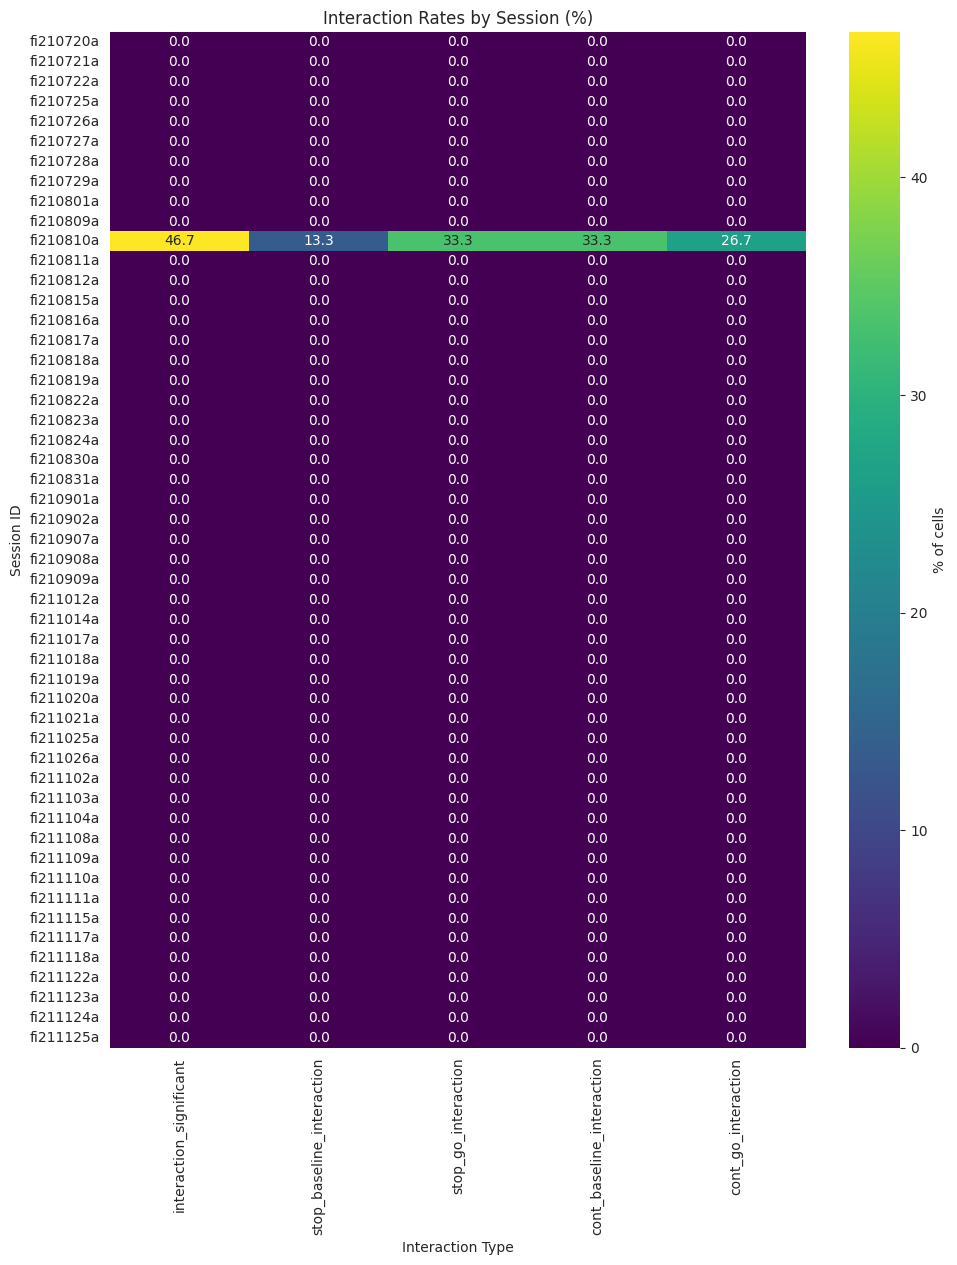

In [35]:
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None

inter_cols = ['interaction_significant', 'stop_baseline_interaction', 'stop_go_interaction', 'cont_baseline_interaction', 'cont_go_interaction']
available = [c for c in inter_cols if c in summary_df]
if not available:
    print('No interaction columns found.')
else:
    inter_numeric = summary_df[available].apply(pd.to_numeric, errors='coerce')
    inter_df = inter_numeric.assign(session_id=summary_df['session_id']).groupby('session_id').mean() * 100
    inter_df = inter_df.fillna(0).astype(float)
    if inter_df.empty:
        print('No interaction data to plot.')
    else:
        plt.figure(figsize=(10, max(4, 0.25*len(inter_df))))
        if sns:
            sns.heatmap(inter_df, annot=True, fmt='.1f', cmap='viridis', cbar_kws={'label': '% of cells'})
        else:
            plt.imshow(inter_df, aspect='auto', cmap='viridis')
            plt.xticks(range(len(inter_df.columns)), inter_df.columns, rotation=45, ha='right')
            plt.yticks(range(len(inter_df.index)), inter_df.index)
        plt.title('Interaction Rates by Session (%)')
        plt.xlabel('Interaction Type')
        plt.ylabel('Session ID')
        plt.tight_layout()
        plt.show()


### Tuning-Space Embedding
PCA over tuning metrics to visualize clustering across sessions.

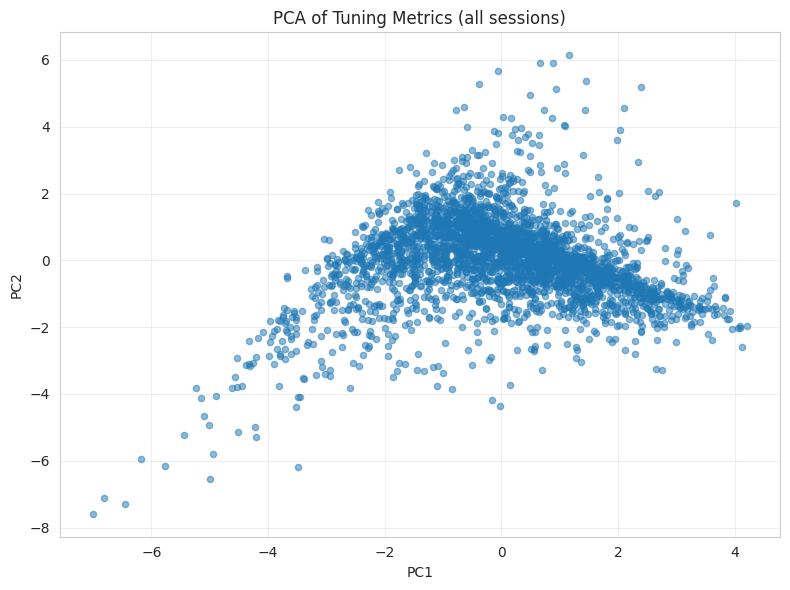

In [36]:

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
except ImportError:
    print('sklearn not available; install scikit-learn to run PCA embedding.')
else:
    feature_cols = [
        'task_mod_p', 'dir_tuning_p', 'stop_mod_p', 'cont_mod_p', 'signal_disc_p', 'go_vs_signal_p',
        'cohens_d_task', 'cohens_d_direction', 'DSI', 'SSI'
    ]
    features = [c for c in feature_cols if c in summary_df]
    emb_df = summary_df[['session_id', 'cell_id'] + features].dropna()
    if len(emb_df) < 10:
        print('Not enough complete rows for PCA embedding.')
    else:
        X = StandardScaler().fit_transform(emb_df[features].values)
        pcs = PCA(n_components=2).fit_transform(X)
        plt.figure(figsize=(8, 6))
        plt.scatter(pcs[:,0], pcs[:,1], c='tab:blue', alpha=0.5, s=20)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('PCA of Tuning Metrics (all sessions)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


### Optional: Window Sweep Sensitivity
Set `run_window_sweep = True` to compare tuning fractions across alternative windows.

In [37]:

run_window_sweep = True  # flip to True to execute (may be slow across sessions)
if not run_window_sweep:
    print('Set run_window_sweep=True to evaluate alternative windows on a subset of sessions (currently off).')
else:
    alt_windows = {
        'short': {'go_task': [0, 200], 'direction': [0, 200], 'signal': [0, 200]},
        'medium': {'go_task': [0, 300], 'direction': [0, 300], 'signal': [0, 300]},
        'long': {'go_task': [0, 500], 'direction': [0, 500], 'signal': [0, 500]},
    }
    orig_windows = WINDOWS.copy()
    subset_sessions = session_ids[:5]  # limit for speed; expand if desired
    sweep_rows = []
    for label, overrides in alt_windows.items():
        WINDOWS.update(overrides)
        tmp_results = []
        for session_id in subset_sessions:
            session_data = cell_df[cell_df['trial_session'] == session_id]
            session = Session(session_data, verbose=False)
            for cell_id in session.cell_ids:
                res = analyze_cell_tuning(session.get_cell(cell_id), verbose=False)
                tmp_results.append(res['summary'])
        WINDOWS.update(orig_windows)
        tmp_df = pd.DataFrame(tmp_results)
        sweep_rows.append({
            'window_label': label,
            'task_modulated_pct': tmp_df['is_task_modulated'].mean() * 100,
            'direction_tuned_pct': tmp_df['is_direction_tuned'].mean() * 100,
            'stop_modulated_pct': tmp_df['is_stop_modulated'].mean() * 100,
            'cont_modulated_pct': tmp_df['is_cont_modulated'].mean() * 100,
            'signal_disc_pct': tmp_df['is_signal_discriminative'].mean() * 100,
            'go_vs_signal_pct': tmp_df['is_go_vs_signal_different'].mean() * 100,
        })
    sweep_df = pd.DataFrame(sweep_rows)
    display(sweep_df)
    print('Note: restore WINDOWS defaults already handled after each sweep; rerun full analysis if adopting a new window config.')


,window_label,task_modulated_pct,direction_tuned_pct,stop_modulated_pct,cont_modulated_pct,signal_disc_pct,go_vs_signal_pct
0,short,43.304843,23.646724,35.612536,35.327635,8.831909,25.641026
1,medium,41.595442,24.786325,35.897436,37.321937,15.384615,35.042735
2,long,40.740741,23.931624,31.054131,37.321937,15.954416,37.891738


Note: restore WINDOWS defaults already handled after each sweep; rerun full analysis if adopting a new window config.
